## 작업 내용

1. 평가 시나리오 정의
- Forecast horizon: 10, 20, 30 cycle
- 여러 forecast origin에서 반복 평가
- Pre-EOL 단기 예측과 EOL crossing 예측 분리
- 06의 긴 Post-EOL 결과는 stress test로 유지

2. 모델 재예측
- 9개 모델에 동일한 origin과 horizon 적용
- NHITS/PatchTST는 horizon별 재학습
- 기존 장기 예측의 앞부분만 자르는 방식은 보조 분석으로만 사용

3. 단기 Capacity 평가
- MAE
- RMSE
- sMAPE
- horizon별 평균과 표준편차
- lead time이 길어질 때 오차 증가 분석

4. Uncertainty 평가
- p10-p90 coverage
- 평균 interval width
- 실제 capacity가 p10 아래로 벗어나는 비율
- deterministic 모델은 평가 대상에서 제외

5. EOL & RUL 파생
- predicted_soh = predicted_capacity / initial_capacity
- predicted_eol_cycle = predicted_soh <= 0.80 최초 cycle
- predicted_rul = predicted_eol_cycle - forecast_origin

6. RUL 평가
- EOL cycle error
- RUL MAE
- EOL crossing 탐지 성공률
- 조기 경보와 지연 경보 구분

7. Leaderboard 생성
- horizon별 최고 모델
- Pre-EOL 최고 모델
- EOL 근처 최고 모델
- Point forecast와 uncertainty 성능을 분리해 평가

## 체크 사항
- 모든 모델이 동일한 origin과 test cycle을 사용해야 합니다.
- 모델 입력에 test capacity, EOL label, 미래 life_stage가 포함되면 안 됩니다.
- 실제 EOL 546은 평가에만 사용해야 합니다.
- Fold별 metric을 먼저 계산한 후 모델 평균을 구해야 합니다.
- 단일 CS2_35 결과라는 한계를 명시해야 합니다.

## 07-1 평가 시나리오
07-1 평가 시나리오는 모든 모델을 동일한 조건에서 비교하기 위한 시험 규칙을 먼저 고정하는 작업.

1. 공정한 비교
- 모든 모델이 같은 시점까지 학습하고 같은 미래 cycle을 예측합니다.
- 모델별로 유리한 구간을 선택하는 것을 방지합니다.

2. 수명 단계별 평가
- 초기·중기·EOL 직전 등 여러 시점에서 성능을 확인합니다.
- 특정 train/test 분할 한 번에 의존하지 않습니다.

3. 예측 거리별 평가
- 10 cycle은 단기 정비 판단
- 20 cycle은 중기 경고
- 30 cycle은 장기 계획에 해당합니다.

4. RUL 평가 조건 확보
- 일반 Pre-EOL 시나리오는 capacity 예측 정확도를 평가합니다.
- EOL crossing 시나리오는 forecast 마지막 구간에 실제 EOL 546을 포함해 RUL과 EOL 오차를 평가합니

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path("..").resolve()

INPUT_PATH = (
    PROJECT_ROOT / "data" / "processed"
    / "paraquet" / "battery_cycles_analysis.parquet"
)

MODEL_FORECAST_PATH = (
    PROJECT_ROOT / "outputs" / "csv"
    / "model_capacity_forecasts_all.csv"
)
MODEL_METRICS_PATH = (
    PROJECT_ROOT / "outputs" / "csv"
    / "model_capacity_metrics_all.csv"
)

EVALUATION_CSV_DIR = (
    PROJECT_ROOT / "outputs" / "csv" / "evaluation"
)
EVALUATION_PARQUET_DIR = (
    PROJECT_ROOT / "outputs" / "parquet" / "evaluation"
)

SCENARIO_OUTPUT_PATH = (
    EVALUATION_CSV_DIR / "rolling_scenarios.csv"
)

HORIZONS = [10, 20, 30]
MIN_TRAIN_ROWS = 180
PRE_EOL_ORIGIN_COUNT = 4
EOL_THRESHOLD = 0.80

In [9]:
df = pd.read_parquet(INPUT_PATH)

series_df = (
    df.loc[df["is_modeling_cycle"]]
    .sort_values("cycle")
    .reset_index(drop=True)
)

model_forecasts_v1 = pd.read_csv(
    MODEL_FORECAST_PATH
)
model_metrics_v1 = pd.read_csv(
    MODEL_METRICS_PATH
)

initial_values = (
    series_df["initial_capacity"]
    .dropna()
    .unique()
)

eol_values = (
    series_df["eol_cycle"]
    .dropna()
    .unique()
)

confirmation_values = (
    series_df["eol_confirmation_cycles"]
    .dropna()
    .unique()
)

assert len(initial_values) == 1
assert len(eol_values) == 1
assert len(confirmation_values) == 1

INITIAL_CAPACITY = float(initial_values[0])
EOL_CYCLE = int(eol_values[0])
EOL_CONFIRMATION_CYCLES = int(
    confirmation_values[0]
)

eol_positions = series_df.index[
    series_df["cycle"] == EOL_CYCLE
].tolist()

assert len(eol_positions) == 1

EOL_POSITION = int(eol_positions[0])

EOL_CONFIRMATION_END_CYCLE = int(
    series_df.iloc[
        EOL_POSITION
        + EOL_CONFIRMATION_CYCLES
        - 1
    ]["cycle"]
)

confirmation_df = series_df.iloc[
    EOL_POSITION:
    EOL_POSITION + EOL_CONFIRMATION_CYCLES
]

assert len(series_df) == 868
assert model_forecasts_v1.shape == (3420, 20)
assert model_metrics_v1.shape == (18, 12)
assert model_forecasts_v1["model_name"].nunique() == 9

assert EOL_CONFIRMATION_CYCLES == 5
assert EOL_CONFIRMATION_END_CYCLE == 550
assert len(confirmation_df) == EOL_CONFIRMATION_CYCLES
assert (
    confirmation_df["soh"] < EOL_THRESHOLD
).all()

print("Modeling rows:", len(series_df))
print("Initial capacity:", INITIAL_CAPACITY)
print("EOL cycle:", EOL_CYCLE)
print("EOL position:", EOL_POSITION)
print("EOL confirmation cycles:", EOL_CONFIRMATION_CYCLES)
print("EOL confirmation end:", EOL_CONFIRMATION_END_CYCLE)

display(
    confirmation_df[
        ["cycle", "capacity_ah", "soh", "life_stage"]
    ]
)

Modeling rows: 868
Initial capacity: 1.1364220858837624
EOL cycle: 546
EOL position: 541
EOL confirmation cycles: 5
EOL confirmation end: 550


,cycle,capacity_ah,soh,life_stage
541,546,0.908205,0.799180,eol
542,547,0.905165,0.796504,post_eol
543,548,0.908010,0.799008,post_eol
544,549,0.904317,0.795758,post_eol
545,550,0.901716,0.793469,post_eol


In [10]:
def make_rolling_split(
    data,
    origin_position,
    horizon,
):
    # Forecast origin까지의 관측값만 train으로 사용합니다.
    train_df = data.iloc[
        :origin_position + 1
    ].copy()

    # Origin 다음 관측값부터 horizon만큼 평가합니다.
    test_df = data.iloc[
        origin_position + 1:
        origin_position + horizon + 1
    ].copy()

    assert len(train_df) >= MIN_TRAIN_ROWS
    assert len(test_df) == horizon
    assert train_df["cycle"].max() < test_df["cycle"].min()

    return train_df, test_df

In [11]:
scenario_rows = []

# 최대 horizon이 EOL 직전까지 끝나는 마지막 origin입니다.
latest_pre_eol_origin_position = (
    EOL_POSITION - max(HORIZONS) - 1
)

# 배터리 수명 구간을 넓게 포함하도록 origin을 균등 배치합니다.
pre_eol_origin_positions = np.unique(
    np.linspace(
        MIN_TRAIN_ROWS - 1,
        latest_pre_eol_origin_position,
        PRE_EOL_ORIGIN_COUNT,
        dtype=int,
    )
)


def append_scenario(
    scenario_id,
    scenario_type,
    origin_position,
    horizon,
    rul_lead_horizon=None,
):
    train_df, test_df = make_rolling_split(
        series_df,
        origin_position,
        horizon,
    )

    origin_row = train_df.iloc[-1]
    origin_cycle = int(origin_row["cycle"])

    confirmation_cycle_set = set(
        range(
            EOL_CYCLE,
            EOL_CYCLE + EOL_CONFIRMATION_CYCLES,
        )
    )

    test_cycle_set = set(
        test_df["cycle"].astype(int)
    )

    includes_eol_confirmation = (
        confirmation_cycle_set
        .issubset(test_cycle_set)
    )

    scenario_rows.append(
        {
            "scenario_id": scenario_id,
            "scenario_type": scenario_type,
            "cell_id": origin_row["cell_id"],
            "origin_position": int(origin_position),
            "forecast_origin": origin_cycle,
            "origin_capacity_ah": float(
                origin_row["capacity_ah"]
            ),
            "origin_soh": float(origin_row["soh"]),
            "origin_below_threshold": bool(
                origin_row["soh"] < EOL_THRESHOLD
            ),
            "horizon": int(horizon),
            "rul_lead_horizon": (
                int(rul_lead_horizon)
                if rul_lead_horizon is not None
                else np.nan
            ),
            "train_rows": len(train_df),
            "test_rows": len(test_df),
            "test_start_cycle": int(
                test_df["cycle"].min()
            ),
            "test_end_cycle": int(
                test_df["cycle"].max()
            ),
            "true_eol_cycle": EOL_CYCLE,
            "true_rul": max(
                EOL_CYCLE - origin_cycle,
                0,
            ),
            "includes_eol": bool(
                test_df["cycle"]
                .eq(EOL_CYCLE)
                .any()
            ),
            "includes_eol_confirmation": bool(
                includes_eol_confirmation
            ),
        }
    )


# 일반적인 Pre-EOL 단기 예측 시나리오입니다.
for origin_number, origin_position in enumerate(
    pre_eol_origin_positions,
    start=1,
):
    origin_cycle = int(
        series_df.iloc[origin_position]["cycle"]
    )

    for horizon in HORIZONS:
        append_scenario(
            scenario_id=(
                f"pre_{origin_number:02d}"
                f"_o{origin_cycle}_h{horizon}"
            ),
            scenario_type="pre_eol_rolling",
            origin_position=int(origin_position),
            horizon=horizon,
        )


# EOL부터 5개 연속 threshold 미만 cycle까지 예측합니다.
for rul_lead_horizon in HORIZONS:
    origin_position = (
        EOL_POSITION - rul_lead_horizon
    )

    origin_cycle = int(
        series_df.iloc[origin_position]["cycle"]
    )

    forecast_horizon = (
        rul_lead_horizon
        + EOL_CONFIRMATION_CYCLES
        - 1
    )

    append_scenario(
        scenario_id=(
            f"eol_o{origin_cycle}"
            f"_lead{rul_lead_horizon}"
            f"_h{forecast_horizon}"
        ),
        scenario_type="eol_crossing",
        origin_position=origin_position,
        horizon=forecast_horizon,
        rul_lead_horizon=rul_lead_horizon,
    )


rolling_scenarios = (
    pd.DataFrame(scenario_rows)
    .sort_values(
        [
            "scenario_type",
            "forecast_origin",
            "horizon",
        ]
    )
    .reset_index(drop=True)
)

display(rolling_scenarios)

,scenario_id,scenario_type,cell_id,origin_position,forecast_origin,origin_capacity_ah,origin_soh,origin_below_threshold,horizon,rul_lead_horizon,train_rows,test_rows,test_start_cycle,test_end_cycle,true_eol_cycle,true_rul,includes_eol,includes_eol_confirmation
0,eol_o516_lead30_h34,eol_crossing,CS2_35,511,516,0.809484,0.712309,True,34,30.0,512,34,517,550,546,30,True,True
1,eol_o526_lead20_h24,eol_crossing,CS2_35,521,526,0.929116,0.817580,False,24,20.0,522,24,527,550,546,20,True,True
2,eol_o536_lead10_h14,eol_crossing,CS2_35,531,536,0.926261,0.815068,False,14,10.0,532,14,537,550,546,10,True,True
3,pre_01_o182_h10,pre_eol_rolling,CS2_35,179,182,1.014713,0.892901,False,10,NaN,180,10,183,192,546,364,False,False
4,pre_01_o182_h20,pre_eol_rolling,CS2_35,179,182,1.014713,0.892901,False,20,NaN,180,20,183,202,546,364,False,False
5,pre_01_o182_h30,pre_eol_rolling,CS2_35,179,182,1.014713,0.892901,False,30,NaN,180,30,183,212,546,364,False,False
6,pre_02_o292_h10,pre_eol_rolling,CS2_35,289,292,0.978900,0.861387,False,10,NaN,290,10,293,302,546,254,False,False
7,pre_02_o292_h20,pre_eol_rolling,CS2_35,289,292,0.978900,0.861387,False,20,NaN,290,20,293,312,546,254,False,False
8,pre_02_o292_h30,pre_eol_rolling,CS2_35,289,292,0.978900,0.861387,False,30,NaN,290,30,293,322,546,254,False,False
9,pre_03_o403_h10,pre_eol_rolling,CS2_35,399,403,0.985188,0.866921,False,10,NaN,400,10,404,413,546,143,False,False


In [12]:
assert len(rolling_scenarios) == 15
assert rolling_scenarios["scenario_id"].is_unique

pre_scenarios = rolling_scenarios.loc[
    rolling_scenarios["scenario_type"]
    == "pre_eol_rolling"
]

eol_scenarios = rolling_scenarios.loc[
    rolling_scenarios["scenario_type"]
    == "eol_crossing"
]

assert len(pre_scenarios) == 12
assert len(eol_scenarios) == 3

# Pre-EOL 시나리오는 EOL과 confirmation 구간을 포함하지 않습니다.
assert not pre_scenarios["includes_eol"].any()
assert not pre_scenarios[
    "includes_eol_confirmation"
].any()

# EOL 시나리오는 EOL과 confirmation 구간 전체를 포함합니다.
assert eol_scenarios["includes_eol"].all()
assert eol_scenarios[
    "includes_eol_confirmation"
].all()

# 일반적인 단기 예측 horizon입니다.
assert set(
    pre_scenarios["horizon"]
) == set(HORIZONS)

# EOL까지 남은 cycle은 10, 20, 30입니다.
assert set(
    eol_scenarios[
        "rul_lead_horizon"
    ].astype(int)
) == set(HORIZONS)

assert set(
    eol_scenarios["true_rul"].astype(int)
) == set(HORIZONS)

# EOL 확인을 위해 4개 cycle을 추가 예측합니다.
assert set(
    eol_scenarios["horizon"]
) == {14, 24, 34}

assert (
    eol_scenarios["test_end_cycle"]
    == EOL_CONFIRMATION_END_CYCLE
).all()

# 전체 15개 scenario의 모델당 예측 행 수입니다.
EXPECTED_ROWS_PER_MODEL = int(
    rolling_scenarios["test_rows"].sum()
)

EXPECTED_TOTAL_FORECAST_ROWS = (
    EXPECTED_ROWS_PER_MODEL * 9
)

assert EXPECTED_ROWS_PER_MODEL == 312
assert EXPECTED_TOTAL_FORECAST_ROWS == 2808

print(
    rolling_scenarios[
        [
            "scenario_id",
            "forecast_origin",
            "origin_soh",
            "origin_below_threshold",
            "horizon",
            "rul_lead_horizon",
            "test_end_cycle",
            "true_rul",
            "includes_eol_confirmation",
        ]
    ].to_string(index=False)
)

print("모델당 forecast rows:", EXPECTED_ROWS_PER_MODEL)
print("전체 forecast rows:", EXPECTED_TOTAL_FORECAST_ROWS)

        scenario_id  forecast_origin  origin_soh  origin_below_threshold  horizon  rul_lead_horizon  test_end_cycle  true_rul  includes_eol_confirmation
eol_o516_lead30_h34              516    0.712309                    True       34              30.0             550        30                       True
eol_o526_lead20_h24              526    0.817580                   False       24              20.0             550        20                       True
eol_o536_lead10_h14              536    0.815068                   False       14              10.0             550        10                       True
    pre_01_o182_h10              182    0.892901                   False       10               NaN             192       364                      False
    pre_01_o182_h20              182    0.892901                   False       20               NaN             202       364                      False
    pre_01_o182_h30              182    0.892901                   False       30 

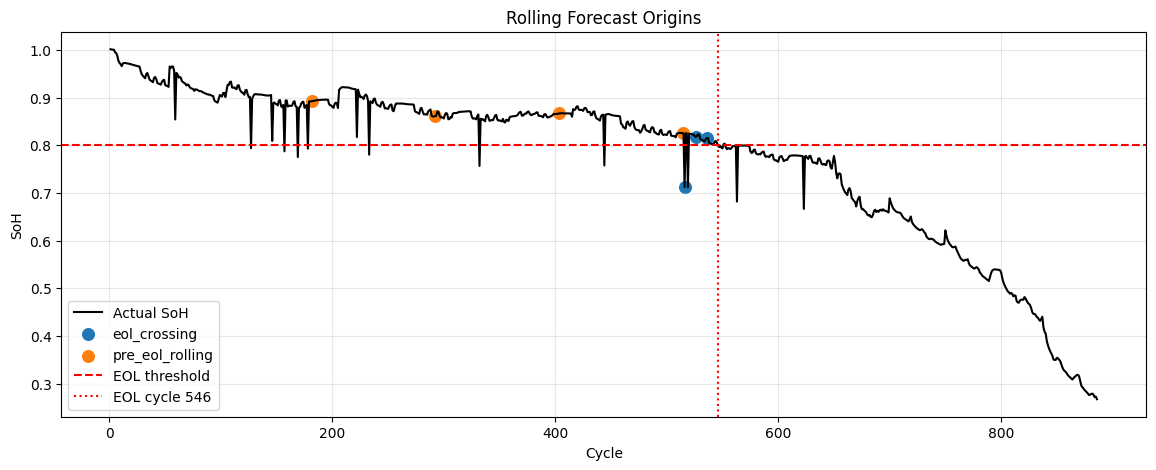

저장 위치: /Users/namduhus/workplace/02_TimeSeries_Model_Project/Battery_TimeSeries_Analysis/outputs/csv/evaluation/rolling_scenarios.csv


In [13]:
EVALUATION_CSV_DIR.mkdir(
    parents=True,
    exist_ok=True,
)
EVALUATION_PARQUET_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

rolling_scenarios.to_csv(
    SCENARIO_OUTPUT_PATH,
    index=False,
)

plt.figure(figsize=(14, 5))

plt.plot(
    series_df["cycle"],
    series_df["soh"],
    color="black",
    linewidth=1.5,
    label="Actual SoH",
)

origin_points = (
    rolling_scenarios[
        [
            "scenario_type",
            "forecast_origin",
            "origin_soh",
        ]
    ]
    .drop_duplicates()
)

for scenario_type, group in origin_points.groupby(
    "scenario_type"
):
    plt.scatter(
        group["forecast_origin"],
        group["origin_soh"],
        s=70,
        label=scenario_type,
    )

plt.axhline(
    EOL_THRESHOLD,
    color="red",
    linestyle="--",
    label="EOL threshold",
)

plt.axvline(
    EOL_CYCLE,
    color="red",
    linestyle=":",
    label=f"EOL cycle {EOL_CYCLE}",
)

plt.xlabel("Cycle")
plt.ylabel("SoH")
plt.title("Rolling Forecast Origins")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

print("저장 위치:", SCENARIO_OUTPUT_PATH)

## 07-2 baseline & ML rolling forecast 

In [14]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

ROLLING_FORECAST_CSV = (
    EVALUATION_CSV_DIR
    / "rolling_baseline_ml_forecasts.csv"
)
ROLLING_FORECAST_PARQUET = (
    EVALUATION_PARQUET_DIR
    / "rolling_baseline_ml_forecasts.parquet"
)
ROLLING_METRICS_CSV = (
    EVALUATION_CSV_DIR
    / "rolling_baseline_ml_metrics.csv"
)
ROLLING_LEADERBOARD_CSV = (
    EVALUATION_CSV_DIR
    / "rolling_baseline_ml_leaderboard.csv"
)

PRIMARY_TARGET = "capacity_ah"
WINDOW = 20

MODEL_FAMILIES = {
    "Persistence": "baseline",
    "MovingAverage": "baseline",
    "LinearTrend": "baseline",
    "RidgeRegression": "machine_learning",
    "RandomForestRegressor": "machine_learning",
}

In [15]:
def mae(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))


def rmse(y_true, y_pred):
    return float(
        np.sqrt(np.mean((y_true - y_pred) ** 2))
    )


def smape(y_true, y_pred):
    denominator = (
        np.abs(y_true) + np.abs(y_pred)
    ) / 2

    valid = denominator > 0

    if not valid.any():
        return 0.0

    return float(
        np.mean(
            np.abs(y_true[valid] - y_pred[valid])
            / denominator[valid]
        ) * 100
    )


def forecast_persistence(train_values, horizon):
    return np.repeat(train_values[-1], horizon)


def forecast_moving_average(
    train_values,
    horizon,
    window,
):
    return np.repeat(
        train_values[-window:].mean(),
        horizon,
    )


def forecast_linear_trend(
    train_values,
    horizon,
    window,
):
    recent_values = train_values[-window:]
    x_train = np.arange(len(recent_values))

    slope, intercept = np.polyfit(
        x_train,
        recent_values,
        deg=1,
    )

    x_future = np.arange(
        len(recent_values),
        len(recent_values) + horizon,
    )

    return slope * x_future + intercept

In [16]:
FEATURE_COLUMNS = [
    "cycle",
    "lag_1",
    "lag_3",
    "lag_5",
    "rolling_mean_5",
    "rolling_mean_10",
    "rolling_std_5",
    "rolling_slope_5",
]


def calculate_slope(values):
    x = np.arange(len(values))

    slope, _ = np.polyfit(
        x,
        values,
        deg=1,
    )

    return float(slope)


def make_supervised_features(data):
    result = data[
        ["cycle", PRIMARY_TARGET]
    ].copy()

    shifted = result[PRIMARY_TARGET].shift(1)

    result["lag_1"] = (
        result[PRIMARY_TARGET].shift(1)
    )
    result["lag_3"] = (
        result[PRIMARY_TARGET].shift(3)
    )
    result["lag_5"] = (
        result[PRIMARY_TARGET].shift(5)
    )
    result["rolling_mean_5"] = (
        shifted.rolling(5).mean()
    )
    result["rolling_mean_10"] = (
        shifted.rolling(10).mean()
    )
    result["rolling_std_5"] = (
        shifted.rolling(5).std()
    )
    result["rolling_slope_5"] = (
        shifted
        .rolling(5)
        .apply(calculate_slope, raw=True)
    )

    return result.dropna().reset_index(drop=True)


def make_next_feature_row(history, next_cycle):
    values = np.asarray(history, dtype=float)

    recent_5 = values[-5:]
    recent_10 = values[-10:]

    row = {
        "cycle": next_cycle,
        "lag_1": values[-1],
        "lag_3": values[-3],
        "lag_5": values[-5],
        "rolling_mean_5": recent_5.mean(),
        "rolling_mean_10": recent_10.mean(),
        "rolling_std_5": recent_5.std(ddof=1),
        "rolling_slope_5": calculate_slope(
            recent_5
        ),
    }

    return pd.DataFrame(
        [row],
        columns=FEATURE_COLUMNS,
    )

In [17]:
def recursive_forecast(
    model,
    train_df,
    test_df,
):
    # 미래 실제값은 history에 추가하지 않습니다.
    history = (
        train_df[PRIMARY_TARGET]
        .to_numpy(dtype=float)
        .tolist()
    )

    raw_predictions = []
    predictions = []

    for cycle in test_df["cycle"]:
        feature_row = make_next_feature_row(
            history,
            int(cycle),
        )

        raw_prediction = float(
            model.predict(feature_row)[0]
        )

        prediction = max(raw_prediction, 0.0)

        raw_predictions.append(raw_prediction)
        predictions.append(prediction)

        # 다음 step에는 이전 예측값을 사용합니다.
        history.append(prediction)

    return (
        np.asarray(raw_predictions),
        np.asarray(predictions),
    )

In [18]:
ml_models_by_origin = {}

unique_origin_positions = sorted(
    rolling_scenarios[
        "origin_position"
    ].unique()
)

for origin_position in unique_origin_positions:
    train_df = series_df.iloc[
        :int(origin_position) + 1
    ].copy()

    supervised_train = make_supervised_features(
        train_df
    )

    X_train = supervised_train[FEATURE_COLUMNS]
    y_train = supervised_train[PRIMARY_TARGET]

    models = {
        "RidgeRegression": make_pipeline(
            StandardScaler(),
            Ridge(alpha=1.0),
        ),
        "RandomForestRegressor": (
            RandomForestRegressor(
                n_estimators=300,
                min_samples_leaf=3,
                random_state=7,
                n_jobs=-1,
            )
        ),
    }

    for model in models.values():
        model.fit(X_train, y_train)

    ml_models_by_origin[
        int(origin_position)
    ] = models

    print(
        "trained origin:",
        int(train_df["cycle"].iloc[-1]),
        "rows:",
        len(train_df),
    )

print(
    "Unique trained origins:",
    len(ml_models_by_origin),
)

trained origin: 182 rows: 180
trained origin: 292 rows: 290
trained origin: 403 rows: 400
trained origin: 515 rows: 511
trained origin: 516 rows: 512
trained origin: 526 rows: 522
trained origin: 536 rows: 532
Unique trained origins: 7


In [19]:
def make_rolling_forecast_frame(
    scenario,
    model_name,
    model_family,
    test_df,
    raw_predictions,
    predictions,
):
    true_capacity = (
        test_df[PRIMARY_TARGET]
        .to_numpy(dtype=float)
    )

    horizon = len(test_df)

    return pd.DataFrame(
        {
            "scenario_id": scenario.scenario_id,
            "scenario_type": scenario.scenario_type,
            "cell_id": scenario.cell_id,
            "model_family": model_family,
            "primary_target": PRIMARY_TARGET,
            "model_name": model_name,
            "forecast_origin": int(
                scenario.forecast_origin
            ),
            "origin_position": int(
                scenario.origin_position
            ),
            "origin_soh": float(
                scenario.origin_soh
            ),
            "origin_below_threshold": bool(
                scenario.origin_below_threshold
            ),
            "horizon": int(scenario.horizon),
            "rul_lead_horizon": (
                scenario.rul_lead_horizon
            ),
            "cycle": test_df["cycle"].to_numpy(),
            "horizon_index": np.arange(
                1, horizon + 1
            ),
            "y_true_capacity": true_capacity,
            "y_pred_capacity_raw": raw_predictions,
            "y_pred_capacity": predictions,
            "y_true_soh": (
                true_capacity / INITIAL_CAPACITY
            ),
            "y_pred_soh": (
                predictions / INITIAL_CAPACITY
            ),
            "initial_capacity": INITIAL_CAPACITY,
            "true_eol_cycle": EOL_CYCLE,
            "true_rul": int(scenario.true_rul),
            # Deterministic 모델은 q50만 제공합니다.
            "y_pred_capacity_q10": np.nan,
            "y_pred_capacity_q50": predictions,
            "y_pred_capacity_q90": np.nan,
            "y_pred_soh_q10": np.nan,
            "y_pred_soh_q50": (
                predictions / INITIAL_CAPACITY
            ),
            "y_pred_soh_q90": np.nan,
        }
    )


def make_rolling_metric_frame(forecast_df):
    true_capacity = (
        forecast_df["y_true_capacity"]
        .to_numpy(dtype=float)
    )
    pred_capacity = (
        forecast_df["y_pred_capacity"]
        .to_numpy(dtype=float)
    )
    true_soh = (
        forecast_df["y_true_soh"]
        .to_numpy(dtype=float)
    )
    pred_soh = (
        forecast_df["y_pred_soh"]
        .to_numpy(dtype=float)
    )

    return {
        "scenario_id": forecast_df[
            "scenario_id"
        ].iloc[0],
        "scenario_type": forecast_df[
            "scenario_type"
        ].iloc[0],
        "forecast_origin": int(
            forecast_df["forecast_origin"].iloc[0]
        ),
        "horizon": int(
            forecast_df["horizon"].iloc[0]
        ),
        "rul_lead_horizon": forecast_df[
            "rul_lead_horizon"
        ].iloc[0],
        "model_family": forecast_df[
            "model_family"
        ].iloc[0],
        "model_name": forecast_df[
            "model_name"
        ].iloc[0],
        "capacity_mae": mae(
            true_capacity,
            pred_capacity,
        ),
        "capacity_rmse": rmse(
            true_capacity,
            pred_capacity,
        ),
        "capacity_smape": smape(
            true_capacity,
            pred_capacity,
        ),
        "soh_mae": mae(true_soh, pred_soh),
        "soh_rmse": rmse(true_soh, pred_soh),
        "soh_smape": smape(true_soh, pred_soh),
        "n": len(forecast_df),
    }

In [20]:
forecast_frames = []
metric_rows = []

for scenario in rolling_scenarios.itertuples(
    index=False
):
    train_df, test_df = make_rolling_split(
        series_df,
        int(scenario.origin_position),
        int(scenario.horizon),
    )

    train_values = (
        train_df[PRIMARY_TARGET]
        .to_numpy(dtype=float)
    )

    horizon = len(test_df)

    prediction_map = {
        "Persistence": forecast_persistence(
            train_values,
            horizon,
        ),
        "MovingAverage": forecast_moving_average(
            train_values,
            horizon,
            WINDOW,
        ),
        "LinearTrend": forecast_linear_trend(
            train_values,
            horizon,
            WINDOW,
        ),
    }

    # Baseline 모델 결과입니다.
    for model_name, raw_predictions in (
        prediction_map.items()
    ):
        predictions = np.clip(
            raw_predictions,
            a_min=0.0,
            a_max=None,
        )

        forecast_df = make_rolling_forecast_frame(
            scenario=scenario,
            model_name=model_name,
            model_family=MODEL_FAMILIES[
                model_name
            ],
            test_df=test_df,
            raw_predictions=raw_predictions,
            predictions=predictions,
        )

        forecast_frames.append(forecast_df)
        metric_rows.append(
            make_rolling_metric_frame(
                forecast_df
            )
        )

    # 같은 origin에서 미리 학습한 ML 모델을 사용합니다.
    ml_models = ml_models_by_origin[
        int(scenario.origin_position)
    ]

    for model_name, model in ml_models.items():
        raw_predictions, predictions = (
            recursive_forecast(
                model,
                train_df,
                test_df,
            )
        )

        forecast_df = make_rolling_forecast_frame(
            scenario=scenario,
            model_name=model_name,
            model_family=MODEL_FAMILIES[
                model_name
            ],
            test_df=test_df,
            raw_predictions=raw_predictions,
            predictions=predictions,
        )

        forecast_frames.append(forecast_df)
        metric_rows.append(
            make_rolling_metric_frame(
                forecast_df
            )
        )

rolling_baseline_ml_forecasts = pd.concat(
    forecast_frames,
    ignore_index=True,
)

rolling_baseline_ml_metrics = (
    pd.DataFrame(metric_rows)
    .sort_values(
        ["scenario_id", "capacity_mae"]
    )
    .reset_index(drop=True)
)

display(rolling_baseline_ml_metrics.head())

,scenario_id,scenario_type,forecast_origin,horizon,rul_lead_horizon,model_family,model_name,capacity_mae,capacity_rmse,capacity_smape,soh_mae,soh_rmse,soh_smape,n
0,eol_o516_lead30_h34,eol_crossing,516,34,30.0,machine_learning,RidgeRegression,0.008801,0.022046,0.978229,0.007744,0.019400,0.978229,34
1,eol_o516_lead30_h34,eol_crossing,516,34,30.0,machine_learning,RandomForestRegressor,0.013644,0.022601,1.503727,0.012006,0.019888,1.503727,34
2,eol_o516_lead30_h34,eol_crossing,516,34,30.0,baseline,MovingAverage,0.014026,0.024354,1.543393,0.012342,0.021431,1.543393,34
3,eol_o516_lead30_h34,eol_crossing,516,34,30.0,baseline,LinearTrend,0.041171,0.042961,4.585453,0.036229,0.037803,4.585453,34
4,eol_o516_lead30_h34,eol_crossing,516,34,30.0,baseline,Persistence,0.109907,0.112076,12.682673,0.096713,0.098621,12.682673,34


In [21]:
EXPECTED_MODEL_NAMES = set(
    MODEL_FAMILIES
)

assert rolling_baseline_ml_forecasts.shape == (
    1560,
    28,
)
assert rolling_baseline_ml_metrics.shape == (
    75,
    14,
)

assert set(
    rolling_baseline_ml_forecasts[
        "model_name"
    ]
) == EXPECTED_MODEL_NAMES

assert (
    rolling_baseline_ml_forecasts
    .groupby("model_name")
    .size()
    .eq(312)
    .all()
)

assert not rolling_baseline_ml_forecasts.duplicated(
    ["scenario_id", "model_name", "cycle"]
).any()

assert (
    rolling_baseline_ml_forecasts[
        "y_pred_capacity"
    ] >= 0
).all()

assert rolling_baseline_ml_forecasts[
    "y_pred_capacity_q10"
].isna().all()

assert rolling_baseline_ml_forecasts[
    "y_pred_capacity_q90"
].isna().all()

assert np.allclose(
    rolling_baseline_ml_forecasts[
        "y_pred_capacity_q50"
    ],
    rolling_baseline_ml_forecasts[
        "y_pred_capacity"
    ],
)

# 같은 scenario의 모든 모델은 같은 실제값을 사용해야 합니다.
actual_counts = (
    rolling_baseline_ml_forecasts
    .groupby(["scenario_id", "cycle"])[
        "y_true_capacity"
    ]
    .nunique()
)

assert actual_counts.eq(1).all()

for scenario in rolling_scenarios.itertuples(
    index=False
):
    scenario_counts = (
        rolling_baseline_ml_forecasts.loc[
            rolling_baseline_ml_forecasts[
                "scenario_id"
            ] == scenario.scenario_id
        ]
        .groupby("model_name")
        .size()
    )

    assert scenario_counts.eq(
        int(scenario.horizon)
    ).all()

print("Rolling baseline/ML validation passed.")

Rolling baseline/ML validation passed.


In [22]:
rolling_baseline_ml_leaderboard = (
    rolling_baseline_ml_metrics
    .groupby(
        [
            "scenario_type",
            "model_family",
            "model_name",
        ],
        as_index=False,
    )
    .agg(
        capacity_mae_mean=(
            "capacity_mae",
            "mean",
        ),
        capacity_mae_std=(
            "capacity_mae",
            "std",
        ),
        capacity_rmse_mean=(
            "capacity_rmse",
            "mean",
        ),
        capacity_smape_mean=(
            "capacity_smape",
            "mean",
        ),
        fold_count=(
            "scenario_id",
            "nunique",
        ),
    )
    .sort_values(
        [
            "scenario_type",
            "capacity_mae_mean",
        ]
    )
    .reset_index(drop=True)
)

display(rolling_baseline_ml_leaderboard)

,scenario_type,model_family,model_name,capacity_mae_mean,capacity_mae_std,capacity_rmse_mean,capacity_smape_mean,fold_count
0,eol_crossing,machine_learning,RidgeRegression,0.006926,0.001792,0.011836,0.762187,3
1,eol_crossing,machine_learning,RandomForestRegressor,0.009203,0.003881,0.012958,1.009672,3
2,eol_crossing,baseline,MovingAverage,0.011673,0.002762,0.016153,1.277101,3
3,eol_crossing,baseline,LinearTrend,0.022543,0.017505,0.024266,2.486246,3
4,eol_crossing,baseline,Persistence,0.045413,0.055860,0.047277,5.182393,3
5,pre_eol_rolling,baseline,Persistence,0.009601,0.008483,0.016454,1.030501,12
6,pre_eol_rolling,machine_learning,RandomForestRegressor,0.013498,0.009483,0.020633,1.422243,12
7,pre_eol_rolling,baseline,LinearTrend,0.013674,0.008073,0.020786,1.439263,12
8,pre_eol_rolling,baseline,MovingAverage,0.014043,0.007801,0.021036,1.472411,12
9,pre_eol_rolling,machine_learning,RidgeRegression,0.024443,0.014859,0.032537,2.537006,12


In [23]:
rolling_baseline_ml_forecasts.to_csv(
    ROLLING_FORECAST_CSV,
    index=False,
)
rolling_baseline_ml_forecasts.to_parquet(
    ROLLING_FORECAST_PARQUET,
    index=False,
)
rolling_baseline_ml_metrics.to_csv(
    ROLLING_METRICS_CSV,
    index=False,
)
rolling_baseline_ml_leaderboard.to_csv(
    ROLLING_LEADERBOARD_CSV,
    index=False,
)

csv_check = pd.read_csv(
    ROLLING_FORECAST_CSV
)
parquet_check = pd.read_parquet(
    ROLLING_FORECAST_PARQUET
)

assert csv_check.shape == parquet_check.shape
assert list(csv_check.columns) == list(
    parquet_check.columns
)

print("Forecast:", csv_check.shape)
print("Metrics:", rolling_baseline_ml_metrics.shape)
print(
    "Leaderboard:",
    rolling_baseline_ml_leaderboard.shape,
)

Forecast: (1560, 28)
Metrics: (75, 14)
Leaderboard: (10, 8)


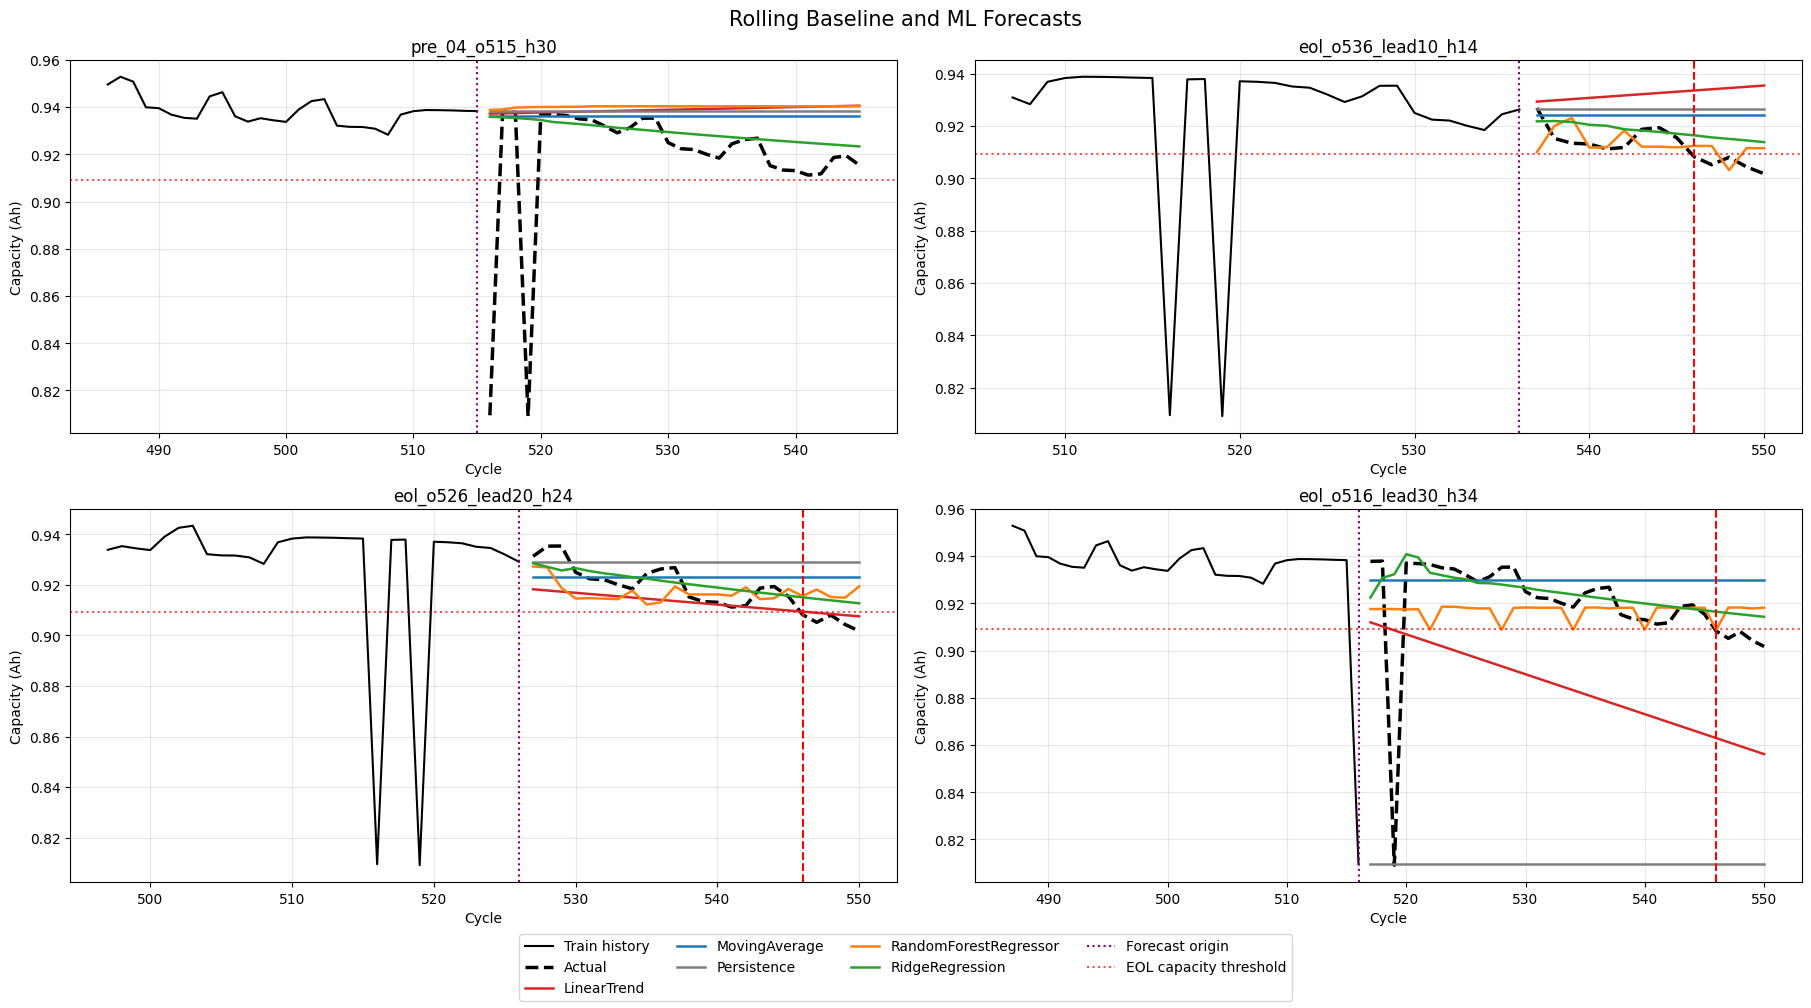

In [24]:
# 대표 시나리오 forecast 비교
VISUAL_SCENARIOS = [
    "pre_04_o515_h30",
    "eol_o536_lead10_h14",
    "eol_o526_lead20_h24",
    "eol_o516_lead30_h34",
]

MODEL_COLORS = {
    "Persistence": "tab:gray",
    "MovingAverage": "tab:blue",
    "LinearTrend": "tab:red",
    "RidgeRegression": "tab:green",
    "RandomForestRegressor": "tab:orange",
}

available_scenarios = set(
    rolling_baseline_ml_forecasts[
        "scenario_id"
    ]
)

missing_scenarios = (
    set(VISUAL_SCENARIOS)
    - available_scenarios
)
assert not missing_scenarios, missing_scenarios

fig, axes = plt.subplots(
    2,
    2,
    figsize=(18, 10),
    constrained_layout=True,
)

for ax, scenario_id in zip(
    axes.flat,
    VISUAL_SCENARIOS,
):
    scenario = (
        rolling_scenarios.loc[
            rolling_scenarios["scenario_id"]
            == scenario_id
        ]
        .iloc[0]
    )

    plot_df = (
        rolling_baseline_ml_forecasts.loc[
            rolling_baseline_ml_forecasts[
                "scenario_id"
            ] == scenario_id
        ]
        .sort_values("cycle")
    )

    train_df, test_df = make_rolling_split(
        series_df,
        int(scenario["origin_position"]),
        int(scenario["horizon"]),
    )

    train_tail = train_df.tail(30)

    # 예측 직전 관측 이력입니다.
    ax.plot(
        train_tail["cycle"],
        train_tail["capacity_ah"],
        color="black",
        linewidth=1.5,
        label="Train history",
    )

    # 실제 미래 capacity입니다.
    ax.plot(
        test_df["cycle"],
        test_df["capacity_ah"],
        color="black",
        linewidth=2.5,
        linestyle="--",
        label="Actual",
    )

    # 모델별 예측 결과입니다.
    for model_name, group in plot_df.groupby(
        "model_name"
    ):
        ax.plot(
            group["cycle"],
            group["y_pred_capacity"],
            color=MODEL_COLORS[model_name],
            linewidth=1.8,
            label=model_name,
        )

    ax.axvline(
        int(scenario["forecast_origin"]),
        color="purple",
        linestyle=":",
        label="Forecast origin",
    )

    ax.axhline(
        INITIAL_CAPACITY * EOL_THRESHOLD,
        color="red",
        linestyle=":",
        alpha=0.7,
        label="EOL capacity threshold",
    )

    # EOL이 test 범위에 포함될 때만 표시합니다.
    if bool(scenario["includes_eol"]):
        ax.axvline(
            EOL_CYCLE,
            color="red",
            linestyle="--",
            label="True EOL",
        )

    ax.set_title(scenario_id)
    ax.set_xlabel("Cycle")
    ax.set_ylabel("Capacity (Ah)")
    ax.grid(alpha=0.3)

handles, labels = axes.flat[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="outside lower center",
    ncol=4,
)

fig.suptitle(
    "Rolling Baseline and ML Forecasts",
    fontsize=15,
)

plt.show()

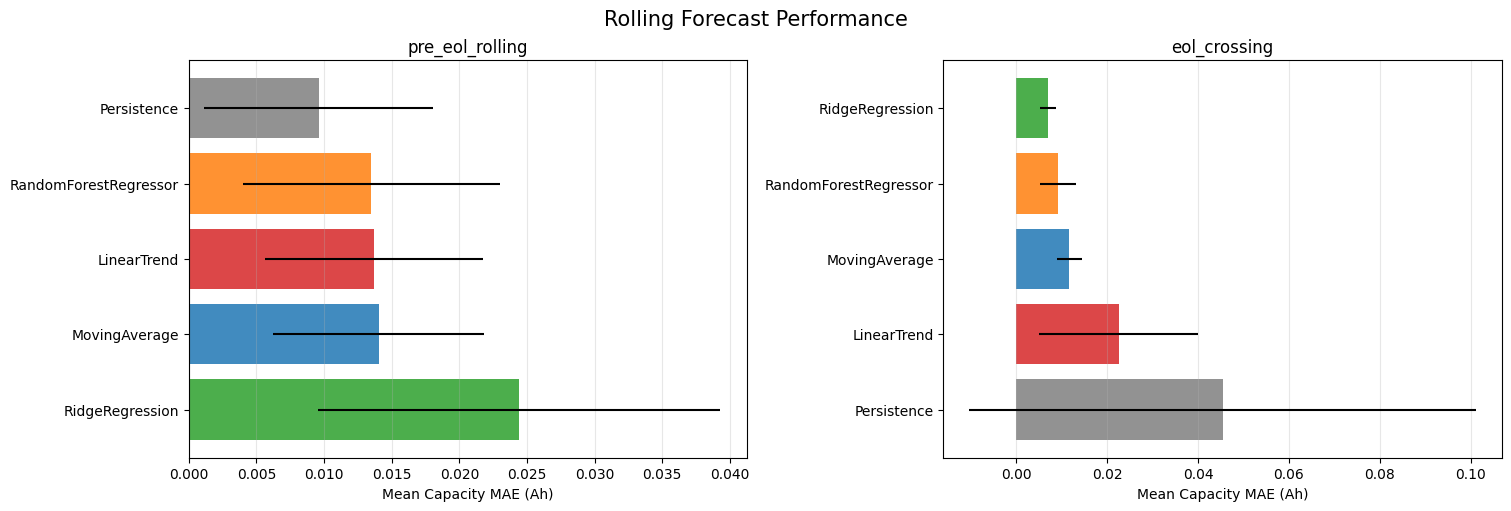

In [25]:
# 시나리오 유형별 평균 MAE
fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5),
    constrained_layout=True,
)

scenario_types = [
    "pre_eol_rolling",
    "eol_crossing",
]

for ax, scenario_type in zip(
    axes,
    scenario_types,
):
    plot_df = (
        rolling_baseline_ml_leaderboard.loc[
            rolling_baseline_ml_leaderboard[
                "scenario_type"
            ] == scenario_type
        ]
        .sort_values(
            "capacity_mae_mean",
            ascending=False,
        )
    )

    colors = [
        MODEL_COLORS[model_name]
        for model_name in plot_df["model_name"]
    ]

    ax.barh(
        plot_df["model_name"],
        plot_df["capacity_mae_mean"],
        xerr=plot_df["capacity_mae_std"].fillna(0),
        color=colors,
        alpha=0.85,
    )

    ax.set_title(scenario_type)
    ax.set_xlabel("Mean Capacity MAE (Ah)")
    ax.grid(axis="x", alpha=0.3)

fig.suptitle(
    "Rolling Forecast Performance",
    fontsize=15,
)

plt.show()

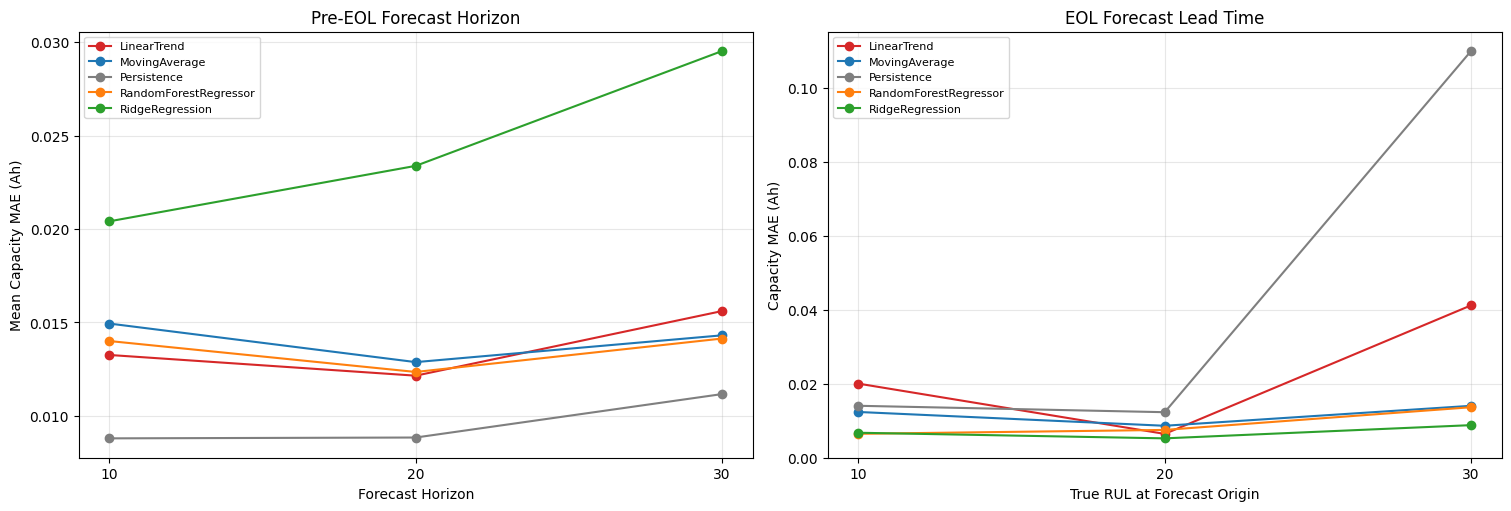

In [26]:
# forecast Horizon별 MAE

pre_horizon_metrics = (
    rolling_baseline_ml_metrics.loc[
        rolling_baseline_ml_metrics[
            "scenario_type"
        ] == "pre_eol_rolling"
    ]
    .groupby(
        ["horizon", "model_name"],
        as_index=False,
    )
    .agg(
        capacity_mae_mean=(
            "capacity_mae",
            "mean",
        ),
        capacity_mae_std=(
            "capacity_mae",
            "std",
        ),
    )
)

eol_lead_metrics = (
    rolling_baseline_ml_metrics.loc[
        rolling_baseline_ml_metrics[
            "scenario_type"
        ] == "eol_crossing"
    ]
    .groupby(
        ["rul_lead_horizon", "model_name"],
        as_index=False,
    )
    .agg(
        capacity_mae_mean=(
            "capacity_mae",
            "mean",
        ),
    )
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5),
    constrained_layout=True,
)

for model_name, group in pre_horizon_metrics.groupby(
    "model_name"
):
    axes[0].plot(
        group["horizon"],
        group["capacity_mae_mean"],
        marker="o",
        color=MODEL_COLORS[model_name],
        label=model_name,
    )

axes[0].set_title("Pre-EOL Forecast Horizon")
axes[0].set_xlabel("Forecast Horizon")
axes[0].set_ylabel("Mean Capacity MAE (Ah)")
axes[0].set_xticks(HORIZONS)
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=8)

for model_name, group in eol_lead_metrics.groupby(
    "model_name"
):
    axes[1].plot(
        group["rul_lead_horizon"],
        group["capacity_mae_mean"],
        marker="o",
        color=MODEL_COLORS[model_name],
        label=model_name,
    )

axes[1].set_title("EOL Forecast Lead Time")
axes[1].set_xlabel("True RUL at Forecast Origin")
axes[1].set_ylabel("Capacity MAE (Ah)")
axes[1].set_xticks(HORIZONS)
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=8)

plt.show()

## 07-3 TimesFM, Chronos-Bolt, NHITS, PatchTST rolling forecast

In [27]:
import torch
import timesfm

from chronos import ChronosBoltPipeline
from neuralforecast import NeuralForecast
from neuralforecast.losses.pytorch import MQLoss
from neuralforecast.models import NHITS, PatchTST

TIMESFM_NAME = "TimesFM_2p5_200M"
CHRONOS_NAME = "ChronosBolt_Base"
NF_MODEL_NAMES = ["NHITS", "PatchTST"]

NF_INPUT_SIZE = 32
NF_MAX_STEPS = 300
NF_RANDOM_SEED = 42

ROLLING_PROB_FORECAST_CSV = (
    EVALUATION_CSV_DIR / "rolling_probabilistic_forecasts.csv"
)
ROLLING_PROB_FORECAST_PARQUET = (
    EVALUATION_PARQUET_DIR / "rolling_probabilistic_forecasts.parquet"
)
ROLLING_PROB_METRICS_CSV = (
    EVALUATION_CSV_DIR / "rolling_probabilistic_metrics.csv"
)
ROLLING_QUANTILE_CSV = (
    EVALUATION_CSV_DIR / "rolling_quantile_diagnostics.csv"
)
ROLLING_ALL_FORECAST_CSV = (
    EVALUATION_CSV_DIR / "rolling_model_forecasts_all.csv"
)
ROLLING_ALL_FORECAST_PARQUET = (
    EVALUATION_PARQUET_DIR / "rolling_model_forecasts_all.parquet"
)
ROLLING_ALL_METRICS_CSV = (
    EVALUATION_CSV_DIR / "rolling_model_metrics_all.csv"
)
ROLLING_ALL_LEADERBOARD_CSV = (
    EVALUATION_CSV_DIR / "rolling_model_leaderboard.csv"
)

/Users/namduhus/workplace/02_TimeSeries_Model_Project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-06-22 14:46:40,062	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-06-22 14:46:40,156	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [28]:
def normalize_quantiles(q10, q50, q90):
    q10 = np.clip(q10, 0.0, None)
    q50 = np.clip(q50, 0.0, None)
    q90 = np.clip(q90, 0.0, None)

    q10 = np.minimum(q10, q50)
    q90 = np.maximum(q90, q50)

    return q10, q50, q90


def add_rolling_quantiles(frame, q10, q50, q90):
    frame["y_pred_capacity_q10"] = q10
    frame["y_pred_capacity_q50"] = q50
    frame["y_pred_capacity_q90"] = q90

    frame["y_pred_soh_q10"] = q10 / INITIAL_CAPACITY
    frame["y_pred_soh_q50"] = q50 / INITIAL_CAPACITY
    frame["y_pred_soh_q90"] = q90 / INITIAL_CAPACITY

    return frame


torch.set_float32_matmul_precision("high")

timesfm_model = (
    timesfm.TimesFM_2p5_200M_torch
    .from_pretrained(
        "google/timesfm-2.5-200m-pytorch"
    )
)

timesfm_model.compile(
    timesfm.ForecastConfig(
        max_context=1024,
        max_horizon=64,
        normalize_inputs=True,
        per_core_batch_size=1,
        use_continuous_quantile_head=True,
        force_flip_invariance=True,
        infer_is_positive=True,
        fix_quantile_crossing=True,
    )
)

chronos_pipeline = ChronosBoltPipeline.from_pretrained(
    "amazon/chronos-bolt-base",
    device_map="cpu",
)

chronos_quantiles = [
    float(value)
    for value in chronos_pipeline.quantiles
]

CHRONOS_Q10 = chronos_quantiles.index(0.1)
CHRONOS_Q50 = chronos_quantiles.index(0.5)
CHRONOS_Q90 = chronos_quantiles.index(0.9)

print("Foundation models loaded.")

Loading weights: 100%|██████████| 269/269 [00:00<00:00, 5409.64it/s]

Foundation models loaded.


In [29]:
foundation_frames = []
foundation_metric_rows = []

for scenario in rolling_scenarios.itertuples(
    index=False
):
    train_df, test_df = make_rolling_split(
        series_df,
        int(scenario.origin_position),
        int(scenario.horizon),
    )

    horizon = len(test_df)
    train_values = (
        train_df[PRIMARY_TARGET]
        .to_numpy(np.float32)
    )

    # TimesFM
    point, quantile = timesfm_model.forecast(
        horizon=horizon,
        inputs=[train_values],
    )

    raw_point = point[0, :horizon].astype(float)
    point_prediction = np.clip(raw_point, 0.0, None)
    quantiles = quantile[0, :horizon]

    q10, q50, q90 = normalize_quantiles(
        quantiles[:, 1],
        quantiles[:, 5],
        quantiles[:, 9],
    )

    timesfm_frame = make_rolling_forecast_frame(
        scenario=scenario,
        model_name=TIMESFM_NAME,
        model_family="foundation_model",
        test_df=test_df,
        raw_predictions=raw_point,
        predictions=point_prediction,
    )

    timesfm_frame = add_rolling_quantiles(
        timesfm_frame, q10, q50, q90
    )

    foundation_frames.append(timesfm_frame)
    foundation_metric_rows.append(
        make_rolling_metric_frame(timesfm_frame)
    )

    # Chronos-Bolt
    context = [
        torch.tensor(
            train_values,
            dtype=torch.float32,
        )
    ]

    chronos_output = chronos_pipeline.predict(
        context,
        prediction_length=horizon,
        limit_prediction_length=False,
    )

    chronos_quantile_values = (
        chronos_output[0]
        .detach()
        .cpu()
        .numpy()
    )

    raw_q10 = chronos_quantile_values[CHRONOS_Q10]
    raw_q50 = chronos_quantile_values[CHRONOS_Q50]
    raw_q90 = chronos_quantile_values[CHRONOS_Q90]

    q10, q50, q90 = normalize_quantiles(
        raw_q10, raw_q50, raw_q90
    )

    chronos_frame = make_rolling_forecast_frame(
        scenario=scenario,
        model_name=CHRONOS_NAME,
        model_family="foundation_model",
        test_df=test_df,
        raw_predictions=raw_q50,
        predictions=q50,
    )

    chronos_frame = add_rolling_quantiles(
        chronos_frame, q10, q50, q90
    )

    foundation_frames.append(chronos_frame)
    foundation_metric_rows.append(
        make_rolling_metric_frame(chronos_frame)
    )

rolling_foundation_forecasts = pd.concat(
    foundation_frames,
    ignore_index=True,
).reindex(
    columns=rolling_baseline_ml_forecasts.columns
)

rolling_foundation_metrics = pd.DataFrame(
    foundation_metric_rows
).reindex(
    columns=rolling_baseline_ml_metrics.columns
)

print("Foundation:", rolling_foundation_forecasts.shape)
display(rolling_foundation_metrics.head())

Foundation: (624, 28)


,scenario_id,scenario_type,forecast_origin,horizon,rul_lead_horizon,model_family,model_name,capacity_mae,capacity_rmse,capacity_smape,soh_mae,soh_rmse,soh_smape,n
0,eol_o516_lead30_h34,eol_crossing,516,34,30.0,foundation_model,TimesFM_2p5_200M,0.020749,0.029895,2.262111,0.018258,0.026306,2.262111,34
1,eol_o516_lead30_h34,eol_crossing,516,34,30.0,foundation_model,ChronosBolt_Base,0.014826,0.024436,1.631522,0.013046,0.021503,1.631523,34
2,eol_o526_lead20_h24,eol_crossing,526,24,20.0,foundation_model,TimesFM_2p5_200M,0.011005,0.012750,1.195972,0.009684,0.011220,1.195972,24
3,eol_o526_lead20_h24,eol_crossing,526,24,20.0,foundation_model,ChronosBolt_Base,0.007083,0.008325,0.771504,0.006233,0.007326,0.771507,24
4,eol_o536_lead10_h14,eol_crossing,536,14,10.0,foundation_model,TimesFM_2p5_200M,0.011346,0.012764,1.238401,0.009984,0.011232,1.238401,14


In [30]:
nf_frames = []
nf_metric_rows = []

for scenario_number, scenario in enumerate(
    rolling_scenarios.itertuples(index=False),
    start=1,
):
    train_df, test_df = make_rolling_split(
        series_df,
        int(scenario.origin_position),
        int(scenario.horizon),
    )

    horizon = len(test_df)

    assert len(train_df) >= (
        NF_INPUT_SIZE + horizon
    )

    nf_train_df = pd.DataFrame(
        {
            "unique_id": (
                train_df["cell_id"]
                .astype(str)
                .to_numpy()
            ),
            "ds": np.arange(len(train_df)),
            "y": (
                train_df[PRIMARY_TARGET]
                .to_numpy(np.float32)
            ),
        }
    )

    models = [
        NHITS(
            h=horizon,
            input_size=NF_INPUT_SIZE,
            loss=MQLoss(level=[80]),
            max_steps=NF_MAX_STEPS,
            scaler_type="robust",
            random_seed=NF_RANDOM_SEED,
            batch_size=1,
            windows_batch_size=128,
            alias="NHITS",
            logger=False,
            enable_checkpointing=False,
            enable_progress_bar=False,
        ),
        PatchTST(
            h=horizon,
            input_size=NF_INPUT_SIZE,
            loss=MQLoss(level=[80]),
            max_steps=NF_MAX_STEPS,
            scaler_type="robust",
            random_seed=NF_RANDOM_SEED,
            batch_size=1,
            windows_batch_size=128,
            patch_len=8,
            stride=4,
            n_heads=4,
            hidden_size=64,
            linear_hidden_size=128,
            encoder_layers=2,
            alias="PatchTST",
            logger=False,
            enable_checkpointing=False,
            enable_progress_bar=False,
        ),
    ]

    nf = NeuralForecast(models=models, freq=1)
    nf.fit(df=nf_train_df)

    predictions = (
        nf.predict()
        .reset_index(drop=True)
        .sort_values("ds")
        .reset_index(drop=True)
    )

    assert len(predictions) == horizon

    for model_name in NF_MODEL_NAMES:
        raw_q10 = predictions[
            f"{model_name}-lo-80"
        ].to_numpy(float)

        raw_q50 = predictions[
            f"{model_name}-median"
        ].to_numpy(float)

        raw_q90 = predictions[
            f"{model_name}-hi-80"
        ].to_numpy(float)

        q10, q50, q90 = normalize_quantiles(
            raw_q10, raw_q50, raw_q90
        )

        frame = make_rolling_forecast_frame(
            scenario=scenario,
            model_name=model_name,
            model_family="deep_learning",
            test_df=test_df,
            raw_predictions=raw_q50,
            predictions=q50,
        )

        frame = add_rolling_quantiles(
            frame, q10, q50, q90
        )

        nf_frames.append(frame)
        nf_metric_rows.append(
            make_rolling_metric_frame(frame)
        )

    print(
        f"[{scenario_number:02d}/15]",
        scenario.scenario_id,
        "completed",
    )

rolling_nf_forecasts = pd.concat(
    nf_frames,
    ignore_index=True,
).reindex(
    columns=rolling_baseline_ml_forecasts.columns
)

rolling_nf_metrics = pd.DataFrame(
    nf_metric_rows
).reindex(
    columns=rolling_baseline_ml_metrics.columns
)

print("NeuralForecast:", rolling_nf_forecasts.shape)
display(rolling_nf_metrics.head())

Seed set to 42
Seed set to 42
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MQLoss        | 3      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 2.5 M  | train
-------------------------------------------------------
2.5 M     Trainable params
3         Non-trainable params
2.5 M     Total params
10.153    Total estimated model params size (MB)
34        Modules in train mode
0         Modules in eval mode
/Users/namduhus/workplace/02_TimeSeries_Model_Project/.venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
`Trainer.fit` stopped: `max_steps=300` reached.
GPU available: True (mps), used: True


[01/15] eol_o516_lead30_h34 completed


/Users/namduhus/workplace/02_TimeSeries_Model_Project/.venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
`Trainer.fit` stopped: `max_steps=300` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name         | Type              | Params | Mode 
-----------------------------------------------------------
0 | loss         | MQLoss            | 3      | train
1 | padder_train | ConstantPad1d     | 0      | train
2 | scaler       | TemporalNorm      | 0      | train
3 | model        | PatchTST_backbone | 104 K  | train
-----------------------------------------------------------
104 K     Trainable params
5         Non-trainable params
104 K     Total params
0.420     Total estimated model params size (MB)
65        Modules in train mode
0         Modules in eval mode
/Users/namduhus/workplace/02_TimeSeries_

[02/15] eol_o526_lead20_h24 completed


`Trainer.fit` stopped: `max_steps=300` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name         | Type              | Params | Mode 
-----------------------------------------------------------
0 | loss         | MQLoss            | 3      | train
1 | padder_train | ConstantPad1d     | 0      | train
2 | scaler       | TemporalNorm      | 0      | train
3 | model        | PatchTST_backbone | 89.6 K | train
-----------------------------------------------------------
89.6 K    Trainable params
5         Non-trainable params
89.6 K    Total params
0.358     Total estimated model params size (MB)
65        Modules in train mode
0         Modules in eval mode
/Users/namduhus/workplace/02_TimeSeries_Model_Project/.venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
`Trainer.fit` stopped: `max_steps=300` r

...

[14/15] pre_04_o515_h20 completed


`Trainer.fit` stopped: `max_steps=300` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name         | Type              | Params | Mode 
-----------------------------------------------------------
0 | loss         | MQLoss            | 3      | train
1 | padder_train | ConstantPad1d     | 0      | train
2 | scaler       | TemporalNorm      | 0      | train
3 | model        | PatchTST_backbone | 114 K  | train
-----------------------------------------------------------
114 K     Trainable params
5         Non-trainable params
114 K     Total params
0.457     Total estimated model params size (MB)
65        Modules in train mode
0         Modules in eval mode
/Users/namduhus/workplace/02_TimeSeries_Model_Project/.venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
`Trainer.fit` stopped: `max_steps=300` r

[15/15] pre_04_o515_h30 completed
NeuralForecast: (624, 28)


/Users/namduhus/workplace/02_TimeSeries_Model_Project/.venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


,scenario_id,scenario_type,forecast_origin,horizon,rul_lead_horizon,model_family,model_name,capacity_mae,capacity_rmse,capacity_smape,soh_mae,soh_rmse,soh_smape,n
0,eol_o516_lead30_h34,eol_crossing,516,34,30.0,deep_learning,NHITS,0.012857,0.024167,1.417236,0.011314,0.021266,1.417236,34
1,eol_o516_lead30_h34,eol_crossing,516,34,30.0,deep_learning,PatchTST,0.026110,0.031282,2.891690,0.022976,0.027527,2.891690,34
2,eol_o526_lead20_h24,eol_crossing,526,24,20.0,deep_learning,NHITS,0.010747,0.013102,1.167126,0.009457,0.011529,1.167126,24
3,eol_o526_lead20_h24,eol_crossing,526,24,20.0,deep_learning,PatchTST,0.006729,0.008203,0.732744,0.005921,0.007219,0.732744,24
4,eol_o536_lead10_h14,eol_crossing,536,14,10.0,deep_learning,NHITS,0.015552,0.019818,1.689794,0.013685,0.017439,1.689794,14


In [32]:
rolling_probabilistic_forecasts = pd.concat(
    [
        rolling_foundation_forecasts,
        rolling_nf_forecasts,
    ],
    ignore_index=True,
)

rolling_probabilistic_metrics = pd.concat(
    [
        rolling_foundation_metrics,
        rolling_nf_metrics,
    ],
    ignore_index=True,
)

assert rolling_probabilistic_forecasts.shape == (
    1248,
    28,
)
assert rolling_probabilistic_metrics.shape == (
    60,
    14,
)

assert (
    rolling_probabilistic_forecasts
    .groupby("model_name")
    .size()
    .eq(312)
    .all()
)

required_forecast_columns = [
    "scenario_id",
    "model_name",
    "cycle",
    "y_true_capacity",
    "y_pred_capacity",
    "y_pred_capacity_q10",
    "y_pred_capacity_q50",
    "y_pred_capacity_q90",
    "y_true_soh",
    "y_pred_soh",
    "y_pred_soh_q10",
    "y_pred_soh_q50",
    "y_pred_soh_q90",
]

assert not (
    rolling_probabilistic_forecasts[
        required_forecast_columns
    ]
    .isna()
    .any()
    .any()
)
assert (
    rolling_probabilistic_forecasts[
        "y_pred_capacity_q10"
    ]
    <= rolling_probabilistic_forecasts[
        "y_pred_capacity_q50"
    ]
).all()

assert (
    rolling_probabilistic_forecasts[
        "y_pred_capacity_q50"
    ]
    <= rolling_probabilistic_forecasts[
        "y_pred_capacity_q90"
    ]
).all()

assert not rolling_probabilistic_forecasts.duplicated(
    ["scenario_id", "model_name", "cycle"]
).any()

# Deterministic 결과와 실제 test 값이 같은지 확인합니다.
reference_actual = (
    rolling_baseline_ml_forecasts[
        ["scenario_id", "cycle", "y_true_capacity"]
    ]
    .drop_duplicates()
    .sort_values(["scenario_id", "cycle"])
    .reset_index(drop=True)
)

for model_name, group in (
    rolling_probabilistic_forecasts
    .groupby("model_name")
):
    model_actual = (
        group[
            ["scenario_id", "cycle", "y_true_capacity"]
        ]
        .sort_values(["scenario_id", "cycle"])
        .reset_index(drop=True)
    )

    pd.testing.assert_frame_equal(
        reference_actual,
        model_actual,
        check_dtype=False,
    )

print("Probabilistic rolling validation passed.")

Probabilistic rolling validation passed.


In [33]:
quantile_rows = []

for (
    scenario_type,
    model_name,
), group in (
    rolling_probabilistic_forecasts
    .groupby(["scenario_type", "model_name"])
):
    covered = (
        (
            group["y_true_capacity"]
            >= group["y_pred_capacity_q10"]
        )
        & (
            group["y_true_capacity"]
            <= group["y_pred_capacity_q90"]
        )
    )

    width = (
        group["y_pred_capacity_q90"]
        - group["y_pred_capacity_q10"]
    )

    quantile_rows.append(
        {
            "scenario_type": scenario_type,
            "model_name": model_name,
            "coverage": covered.mean(),
            "mean_interval_width": width.mean(),
            "below_q10_rate": (
                group["y_true_capacity"]
                < group["y_pred_capacity_q10"]
            ).mean(),
            "above_q90_rate": (
                group["y_true_capacity"]
                > group["y_pred_capacity_q90"]
            ).mean(),
        }
    )

rolling_quantile_diagnostics = (
    pd.DataFrame(quantile_rows)
    .sort_values(
        ["scenario_type", "model_name"]
    )
    .reset_index(drop=True)
)

display(rolling_quantile_diagnostics)

,scenario_type,model_name,coverage,mean_interval_width,below_q10_rate,above_q90_rate
0,eol_crossing,ChronosBolt_Base,0.958333,0.055277,0.027778,0.013889
1,eol_crossing,NHITS,0.250000,0.015033,0.569444,0.180556
2,eol_crossing,PatchTST,0.944444,0.052720,0.013889,0.041667
3,eol_crossing,TimesFM_2p5_200M,0.986111,0.057855,0.013889,0.000000
4,pre_eol_rolling,ChronosBolt_Base,0.820833,0.034936,0.125000,0.054167
5,pre_eol_rolling,NHITS,0.237500,0.007344,0.287500,0.475000
6,pre_eol_rolling,PatchTST,0.504167,0.018713,0.150000,0.345833
7,pre_eol_rolling,TimesFM_2p5_200M,0.937500,0.051184,0.037500,0.025000


In [34]:
rolling_model_forecasts_all = pd.concat(
    [
        rolling_baseline_ml_forecasts,
        rolling_probabilistic_forecasts,
    ],
    ignore_index=True,
).sort_values(
    ["scenario_id", "model_name", "cycle"]
).reset_index(drop=True)

rolling_model_metrics_all = pd.concat(
    [
        rolling_baseline_ml_metrics,
        rolling_probabilistic_metrics,
    ],
    ignore_index=True,
).sort_values(
    ["scenario_id", "capacity_mae"]
).reset_index(drop=True)

rolling_model_leaderboard = (
    rolling_model_metrics_all
    .groupby(
        [
            "scenario_type",
            "model_family",
            "model_name",
        ],
        as_index=False,
    )
    .agg(
        capacity_mae_mean=(
            "capacity_mae",
            "mean",
        ),
        capacity_mae_std=(
            "capacity_mae",
            "std",
        ),
        capacity_rmse_mean=(
            "capacity_rmse",
            "mean",
        ),
        capacity_smape_mean=(
            "capacity_smape",
            "mean",
        ),
        fold_count=(
            "scenario_id",
            "nunique",
        ),
    )
    .sort_values(
        ["scenario_type", "capacity_mae_mean"]
    )
    .reset_index(drop=True)
)

assert rolling_model_forecasts_all.shape == (
    2808,
    28,
)
assert rolling_model_metrics_all.shape == (
    135,
    14,
)
assert rolling_model_leaderboard.shape == (
    18,
    8,
)

assert (
    rolling_model_forecasts_all
    .groupby("model_name")
    .size()
    .eq(312)
    .all()
)

assert not rolling_model_forecasts_all.duplicated(
    ["scenario_id", "model_name", "cycle"]
).any()

rolling_probabilistic_forecasts.to_csv(
    ROLLING_PROB_FORECAST_CSV,
    index=False,
)
rolling_probabilistic_forecasts.to_parquet(
    ROLLING_PROB_FORECAST_PARQUET,
    index=False,
)
rolling_probabilistic_metrics.to_csv(
    ROLLING_PROB_METRICS_CSV,
    index=False,
)
rolling_quantile_diagnostics.to_csv(
    ROLLING_QUANTILE_CSV,
    index=False,
)

rolling_model_forecasts_all.to_csv(
    ROLLING_ALL_FORECAST_CSV,
    index=False,
)
rolling_model_forecasts_all.to_parquet(
    ROLLING_ALL_FORECAST_PARQUET,
    index=False,
)
rolling_model_metrics_all.to_csv(
    ROLLING_ALL_METRICS_CSV,
    index=False,
)
rolling_model_leaderboard.to_csv(
    ROLLING_ALL_LEADERBOARD_CSV,
    index=False,
)

display(rolling_model_leaderboard)

,scenario_type,model_family,model_name,capacity_mae_mean,capacity_mae_std,capacity_rmse_mean,capacity_smape_mean,fold_count
0,eol_crossing,machine_learning,RidgeRegression,0.006926,0.001792,0.011836,0.762187,3
1,eol_crossing,machine_learning,RandomForestRegressor,0.009203,0.003881,0.012958,1.009672,3
2,eol_crossing,foundation_model,ChronosBolt_Base,0.010546,0.003936,0.014586,1.155312,3
3,eol_crossing,baseline,MovingAverage,0.011673,0.002762,0.016153,1.277101,3
4,eol_crossing,deep_learning,NHITS,0.013052,0.002408,0.019029,1.424719,3
5,eol_crossing,deep_learning,PatchTST,0.013422,0.010994,0.015869,1.478798,3
6,eol_crossing,foundation_model,TimesFM_2p5_200M,0.014367,0.005530,0.018470,1.565494,3
7,eol_crossing,baseline,LinearTrend,0.022543,0.017505,0.024266,2.486246,3
8,eol_crossing,baseline,Persistence,0.045413,0.055860,0.047277,5.182393,3
9,pre_eol_rolling,foundation_model,TimesFM_2p5_200M,0.008939,0.008364,0.015955,0.963789,12


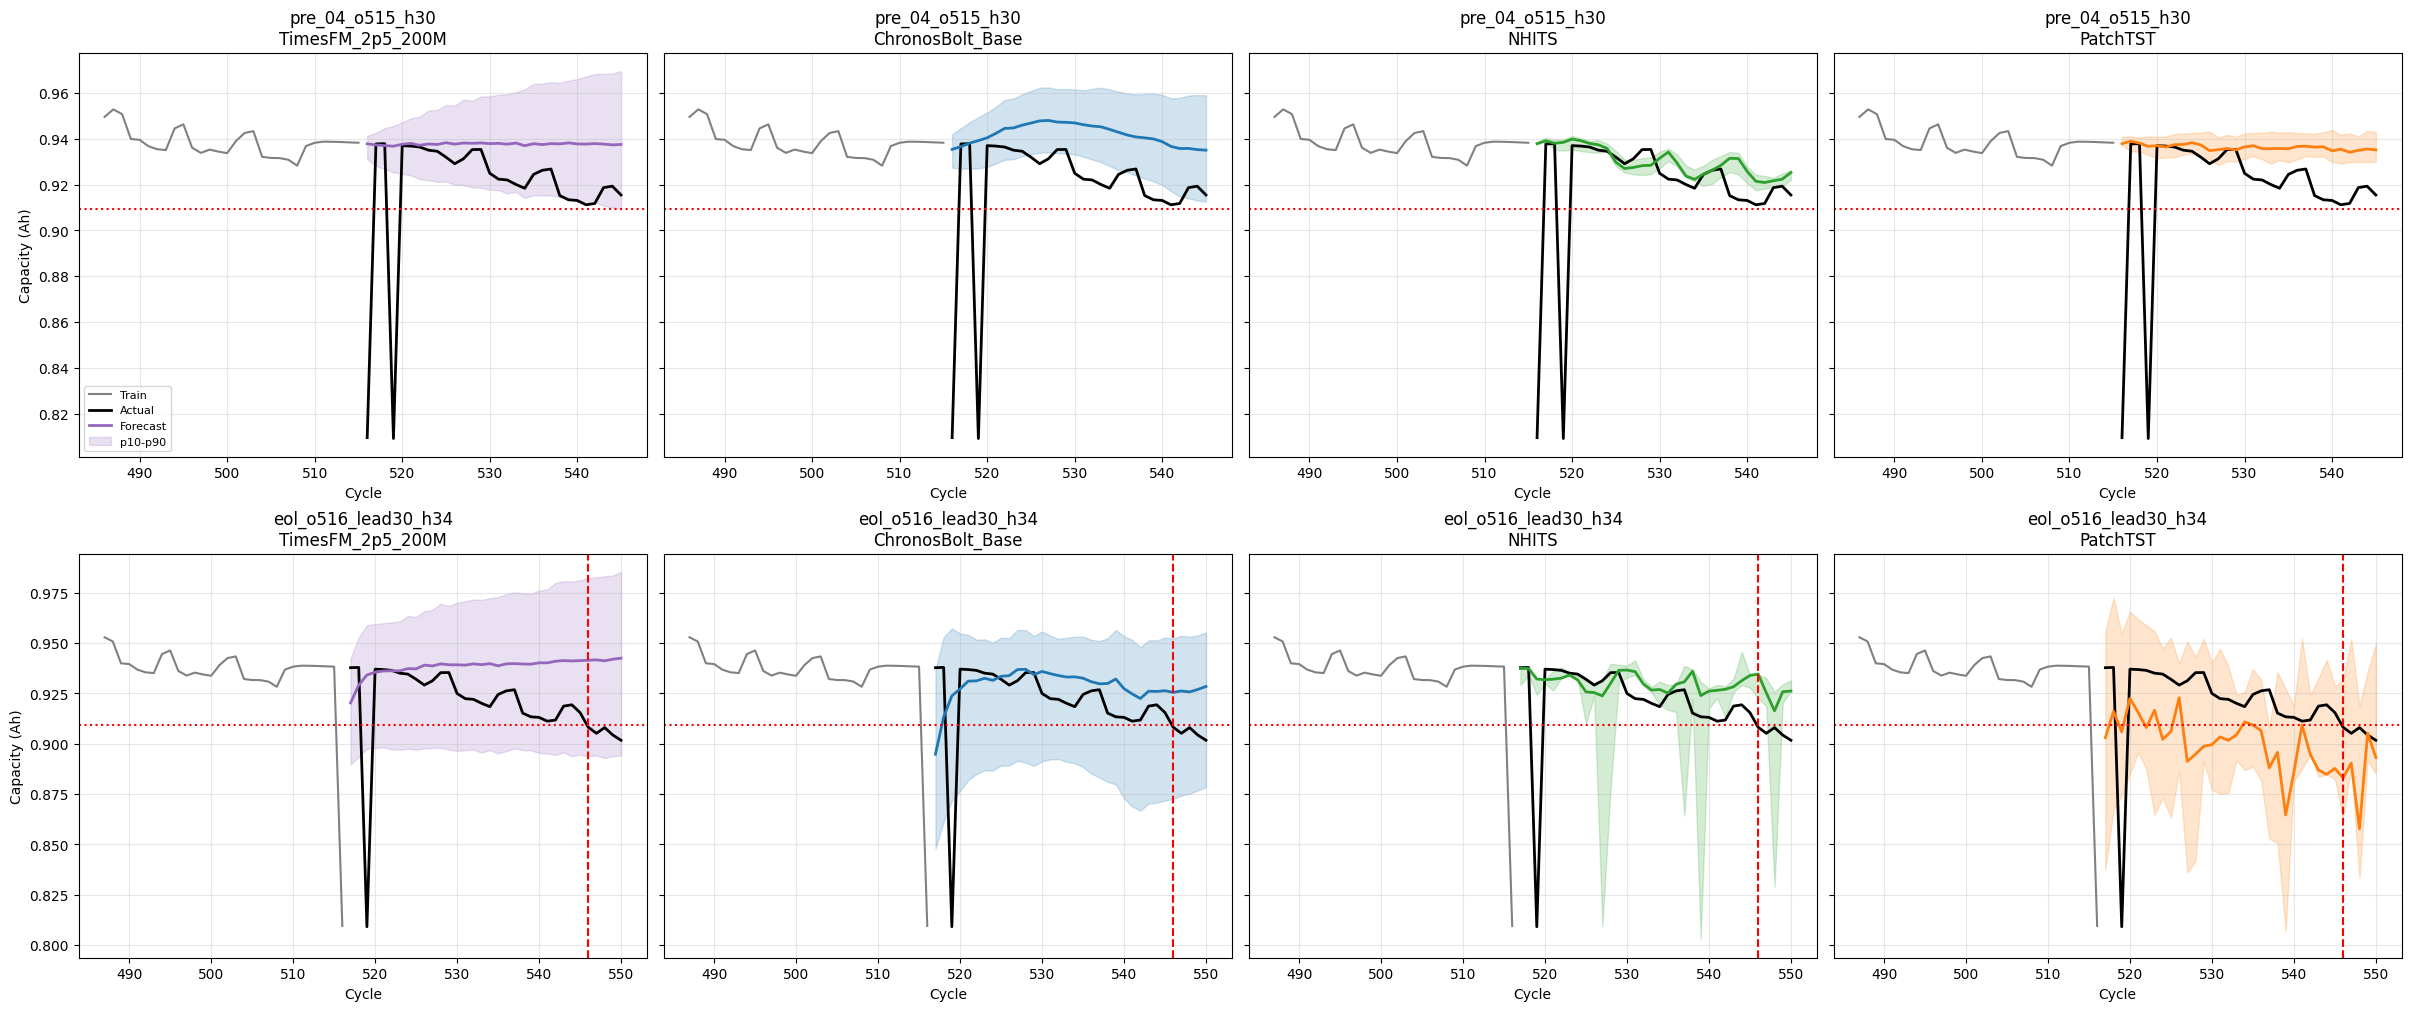

In [35]:
VISUAL_SCENARIOS = [
    "pre_04_o515_h30",
    "eol_o516_lead30_h34",
]

VISUAL_MODELS = [
    TIMESFM_NAME,
    CHRONOS_NAME,
    "NHITS",
    "PatchTST",
]

MODEL_COLORS = {
    TIMESFM_NAME: "tab:purple",
    CHRONOS_NAME: "tab:blue",
    "NHITS": "tab:green",
    "PatchTST": "tab:orange",
}

fig, axes = plt.subplots(
    len(VISUAL_SCENARIOS),
    len(VISUAL_MODELS),
    figsize=(24, 10),
    sharey="row",
    constrained_layout=True,
)

for row_index, scenario_id in enumerate(
    VISUAL_SCENARIOS
):
    scenario = rolling_scenarios.loc[
        rolling_scenarios["scenario_id"]
        == scenario_id
    ].iloc[0]

    train_df, _ = make_rolling_split(
        series_df,
        int(scenario["origin_position"]),
        int(scenario["horizon"]),
    )

    for column_index, model_name in enumerate(
        VISUAL_MODELS
    ):
        ax = axes[row_index, column_index]

        plot_df = (
            rolling_probabilistic_forecasts.loc[
                (
                    rolling_probabilistic_forecasts[
                        "scenario_id"
                    ] == scenario_id
                )
                & (
                    rolling_probabilistic_forecasts[
                        "model_name"
                    ] == model_name
                )
            ]
            .sort_values("cycle")
        )

        ax.plot(
            train_df.tail(30)["cycle"],
            train_df.tail(30)["capacity_ah"],
            color="gray",
            label="Train",
        )
        ax.plot(
            plot_df["cycle"],
            plot_df["y_true_capacity"],
            color="black",
            linewidth=2,
            label="Actual",
        )
        ax.plot(
            plot_df["cycle"],
            plot_df["y_pred_capacity"],
            color=MODEL_COLORS[model_name],
            linewidth=2,
            label="Forecast",
        )
        ax.fill_between(
            plot_df["cycle"],
            plot_df["y_pred_capacity_q10"],
            plot_df["y_pred_capacity_q90"],
            color=MODEL_COLORS[model_name],
            alpha=0.2,
            label="p10-p90",
        )
        ax.axhline(
            INITIAL_CAPACITY * EOL_THRESHOLD,
            color="red",
            linestyle=":",
        )

        if bool(scenario["includes_eol"]):
            ax.axvline(
                EOL_CYCLE,
                color="red",
                linestyle="--",
            )

        ax.set_title(
            f"{scenario_id}\n{model_name}"
        )
        ax.set_xlabel("Cycle")
        ax.grid(alpha=0.3)

axes[0, 0].legend(fontsize=8)
axes[0, 0].set_ylabel("Capacity (Ah)")
axes[1, 0].set_ylabel("Capacity (Ah)")

plt.show()

## 07-4 EOL 및 RUL 평가

In [36]:
RUL_PREDICTIONS_CSV = (
    EVALUATION_CSV_DIR / "rolling_rul_predictions.csv"
)
RUL_PREDICTIONS_PARQUET = (
    EVALUATION_PARQUET_DIR / "rolling_rul_predictions.parquet"
)
RUL_METRICS_CSV = (
    EVALUATION_CSV_DIR / "rolling_rul_metrics.csv"
)
DECISION_LEADERBOARD_CSV = (
    EVALUATION_CSV_DIR
    / "rolling_decision_leaderboard.csv"
)
RISK_SUMMARY_CSV = (
    EVALUATION_CSV_DIR / "rolling_risk_summary.csv"
)

In [37]:
def find_sustained_eol_cycle(
    cycles,
    predicted_soh,
    threshold=EOL_THRESHOLD,
    confirmation_cycles=EOL_CONFIRMATION_CYCLES,
):
    cycles = np.asarray(cycles)
    predicted_soh = np.asarray(
        predicted_soh,
        dtype=float,
    )

    # Quantile을 지원하지 않는 경우입니다.
    if np.isnan(predicted_soh).any():
        return np.nan

    below_threshold = (
        predicted_soh < threshold
    )

    max_start = (
        len(below_threshold)
        - confirmation_cycles
        + 1
    )

    for start_index in range(max_start):
        confirmation_window = below_threshold[
            start_index:
            start_index + confirmation_cycles
        ]

        if confirmation_window.all():
            # 연속 하락이 시작된 cycle을 EOL로 반환합니다.
            return int(cycles[start_index])

    return np.nan


def eol_cycle_to_rul(
    predicted_eol_cycle,
    forecast_origin,
):
    if pd.isna(predicted_eol_cycle):
        return np.nan

    return int(
        predicted_eol_cycle
        - forecast_origin
    )


def classify_risk(soh):
    if soh >= 0.90:
        return "normal"

    if soh >= EOL_THRESHOLD:
        return "warning"

    return "critical"

In [38]:
scenario_lookup = (
    rolling_scenarios
    .set_index("scenario_id")
)

rul_rows = []

for (
    scenario_id,
    model_name,
), group in rolling_model_forecasts_all.groupby(
    ["scenario_id", "model_name"]
):
    group = group.sort_values("cycle")
    scenario = scenario_lookup.loc[scenario_id]

    cycles = group["cycle"].to_numpy()

    predicted_eol_q10 = find_sustained_eol_cycle(
        cycles,
        group["y_pred_soh_q10"],
    )
    predicted_eol_q50 = find_sustained_eol_cycle(
        cycles,
        group["y_pred_soh_q50"],
    )
    predicted_eol_q90 = find_sustained_eol_cycle(
        cycles,
        group["y_pred_soh_q90"],
    )

    predicted_rul_q10 = eol_cycle_to_rul(
        predicted_eol_q10,
        int(scenario["forecast_origin"]),
    )
    predicted_rul_q50 = eol_cycle_to_rul(
        predicted_eol_q50,
        int(scenario["forecast_origin"]),
    )
    predicted_rul_q90 = eol_cycle_to_rul(
        predicted_eol_q90,
        int(scenario["forecast_origin"]),
    )

    true_event_in_horizon = bool(
        scenario["includes_eol_confirmation"]
    )

    predicted_event = not pd.isna(
        predicted_eol_q50
    )

    if true_event_in_horizon and predicted_event:
        event_status = "true_positive"
    elif true_event_in_horizon:
        event_status = "false_negative"
    elif predicted_event:
        event_status = "false_positive"
    else:
        event_status = "true_negative"

    rul_error = np.nan

    if true_event_in_horizon and predicted_event:
        rul_error = (
            predicted_rul_q50
            - int(scenario["true_rul"])
        )

    interval_available = (
        not pd.isna(predicted_rul_q10)
        and not pd.isna(predicted_rul_q90)
    )

    interval_covers_true = np.nan

    if interval_available:
        interval_covers_true = bool(
            predicted_rul_q10
            <= int(scenario["true_rul"])
            <= predicted_rul_q90
        )

    supports_quantiles = not (
        group["y_pred_soh_q10"].isna().all()
    )

    rul_rows.append(
        {
            "scenario_id": scenario_id,
            "scenario_type": scenario["scenario_type"],
            "cell_id": scenario["cell_id"],
            "model_family": group[
                "model_family"
            ].iloc[0],
            "model_name": model_name,
            "forecast_origin": int(
                scenario["forecast_origin"]
            ),
            "origin_soh": float(
                scenario["origin_soh"]
            ),
            "origin_risk_level": classify_risk(
                float(scenario["origin_soh"])
            ),
            "origin_below_threshold": bool(
                scenario["origin_below_threshold"]
            ),
            "horizon": int(scenario["horizon"]),
            "rul_lead_horizon": scenario[
                "rul_lead_horizon"
            ],
            "forecast_end_cycle": int(
                group["cycle"].max()
            ),
            "true_eol_cycle": EOL_CYCLE,
            "true_rul": int(scenario["true_rul"]),
            "true_event_in_horizon": (
                true_event_in_horizon
            ),
            "supports_quantiles": supports_quantiles,
            "predicted_eol_cycle": predicted_eol_q50,
            "predicted_rul": predicted_rul_q50,
            "is_censored": not predicted_event,
            "event_status": event_status,
            "eol_cycle_error": rul_error,
            "rul_error": rul_error,
            "abs_rul_error": (
                abs(rul_error)
                if not pd.isna(rul_error)
                else np.nan
            ),
            "predicted_eol_cycle_q10": (
                predicted_eol_q10
            ),
            "predicted_eol_cycle_q50": (
                predicted_eol_q50
            ),
            "predicted_eol_cycle_q90": (
                predicted_eol_q90
            ),
            "predicted_rul_q10": predicted_rul_q10,
            "predicted_rul_q50": predicted_rul_q50,
            "predicted_rul_q90": predicted_rul_q90,
            "rul_interval_available": (
                interval_available
            ),
            "rul_interval_covers_true": (
                interval_covers_true
            ),
        }
    )

rolling_rul_predictions = (
    pd.DataFrame(rul_rows)
    .sort_values(
        ["scenario_id", "model_name"]
    )
    .reset_index(drop=True)
)

display(rolling_rul_predictions.head())

,scenario_id,scenario_type,cell_id,model_family,model_name,forecast_origin,origin_soh,origin_risk_level,origin_below_threshold,horizon,...,rul_error,abs_rul_error,predicted_eol_cycle_q10,predicted_eol_cycle_q50,predicted_eol_cycle_q90,predicted_rul_q10,predicted_rul_q50,predicted_rul_q90,rul_interval_available,rul_interval_covers_true
0,eol_o516_lead30_h34,eol_crossing,CS2_35,foundation_model,ChronosBolt_Base,516,0.712309,critical,True,34,...,NaN,NaN,517.0,NaN,NaN,1.0,NaN,NaN,False,NaN
1,eol_o516_lead30_h34,eol_crossing,CS2_35,baseline,LinearTrend,516,0.712309,critical,True,34,...,-27.0,27.0,NaN,519.0,NaN,NaN,3.0,NaN,False,NaN
2,eol_o516_lead30_h34,eol_crossing,CS2_35,baseline,MovingAverage,516,0.712309,critical,True,34,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN
3,eol_o516_lead30_h34,eol_crossing,CS2_35,deep_learning,NHITS,516,0.712309,critical,True,34,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN
4,eol_o516_lead30_h34,eol_crossing,CS2_35,deep_learning,PatchTST,516,0.712309,critical,True,34,...,-19.0,19.0,517.0,527.0,NaN,1.0,11.0,NaN,False,NaN


In [39]:
assert len(rolling_rul_predictions) == 135

assert (
    rolling_rul_predictions
    .groupby("model_name")
    .size()
    .eq(15)
    .all()
)

assert (
    rolling_rul_predictions[
        "true_event_in_horizon"
    ].sum()
    == 27
)

assert (
    (~rolling_rul_predictions[
        "true_event_in_horizon"
    ]).sum()
    == 108
)

valid_statuses = {
    "true_positive",
    "false_positive",
    "true_negative",
    "false_negative",
}

assert set(
    rolling_rul_predictions["event_status"]
).issubset(valid_statuses)

detected_rows = rolling_rul_predictions.loc[
    ~rolling_rul_predictions[
        "predicted_eol_cycle"
    ].isna()
]

assert (
    detected_rows["predicted_eol_cycle"]
    >= detected_rows["forecast_origin"]
).all()

assert (
    detected_rows["predicted_eol_cycle"]
    <= detected_rows["forecast_end_cycle"]
).all()

assert np.allclose(
    detected_rows["predicted_rul"],
    (
        detected_rows["predicted_eol_cycle"]
        - detected_rows["forecast_origin"]
    ),
)

# Quantile EOL이 모두 존재하면 q10 <= q50 <= q90이어야 합니다.
quantile_complete = (
    rolling_rul_predictions[
        [
            "predicted_eol_cycle_q10",
            "predicted_eol_cycle_q50",
            "predicted_eol_cycle_q90",
        ]
    ]
    .notna()
    .all(axis=1)
)

complete_rows = rolling_rul_predictions.loc[
    quantile_complete
]

assert (
    complete_rows["predicted_eol_cycle_q10"]
    <= complete_rows["predicted_eol_cycle_q50"]
).all()

assert (
    complete_rows["predicted_eol_cycle_q50"]
    <= complete_rows["predicted_eol_cycle_q90"]
).all()

print("EOL/RUL prediction validation passed.")

EOL/RUL prediction validation passed.


In [40]:
def safe_ratio(numerator, denominator):
    if denominator == 0:
        return np.nan

    return float(numerator / denominator)


rul_metric_rows = []

for model_name, group in rolling_rul_predictions.groupby(
    "model_name"
):
    true_positive = int(
        (group["event_status"] == "true_positive").sum()
    )
    false_negative = int(
        (group["event_status"] == "false_negative").sum()
    )
    false_positive = int(
        (group["event_status"] == "false_positive").sum()
    )
    true_negative = int(
        (group["event_status"] == "true_negative").sum()
    )

    detected_true_events = group.loc[
        (
            group["true_event_in_horizon"]
        )
        & (
            ~group["is_censored"]
        )
    ]

    errors = (
        detected_true_events["rul_error"]
        .dropna()
        .to_numpy(dtype=float)
    )

    supports_quantiles = bool(
        group["supports_quantiles"].iloc[0]
    )

    true_event_rows = group.loc[
        group["true_event_in_horizon"]
    ]

    if supports_quantiles:
        q10_detection_rate = (
            true_event_rows[
                "predicted_eol_cycle_q10"
            ]
            .notna()
            .mean()
        )
        q50_detection_rate = (
            true_event_rows[
                "predicted_eol_cycle_q50"
            ]
            .notna()
            .mean()
        )
        q90_detection_rate = (
            true_event_rows[
                "predicted_eol_cycle_q90"
            ]
            .notna()
            .mean()
        )
    else:
        q10_detection_rate = np.nan
        q50_detection_rate = np.nan
        q90_detection_rate = np.nan

    interval_rows = true_event_rows.loc[
        true_event_rows[
            "rul_interval_available"
        ]
    ]

    rul_metric_rows.append(
        {
            "model_family": group[
                "model_family"
            ].iloc[0],
            "model_name": model_name,
            "true_positive": true_positive,
            "false_negative": false_negative,
            "false_positive": false_positive,
            "true_negative": true_negative,
            "precision": safe_ratio(
                true_positive,
                true_positive + false_positive,
            ),
            "eol_detection_rate": safe_ratio(
                true_positive,
                true_positive + false_negative,
            ),
            "specificity": safe_ratio(
                true_negative,
                true_negative + false_positive,
            ),
            "false_alarm_rate": safe_ratio(
                false_positive,
                false_positive + true_negative,
            ),
            "rul_detected_count": len(
                detected_true_events
            ),
            "rul_mae_detected": (
                float(np.mean(np.abs(errors)))
                if len(errors) > 0
                else np.nan
            ),
            "rul_rmse_detected": (
                float(np.sqrt(np.mean(errors ** 2)))
                if len(errors) > 0
                else np.nan
            ),
            "rul_bias_detected": (
                float(np.mean(errors))
                if len(errors) > 0
                else np.nan
            ),
            "early_warning_count": int(
                (errors < 0).sum()
            ),
            "late_warning_count": int(
                (errors > 0).sum()
            ),
            "exact_warning_count": int(
                (errors == 0).sum()
            ),
            "q10_detection_rate": q10_detection_rate,
            "q50_detection_rate": q50_detection_rate,
            "q90_detection_rate": q90_detection_rate,
            "rul_interval_count": len(interval_rows),
            "rul_interval_coverage": (
                interval_rows[
                    "rul_interval_covers_true"
                ].mean()
                if len(interval_rows) > 0
                else np.nan
            ),
        }
    )

rolling_rul_metrics = (
    pd.DataFrame(rul_metric_rows)
    .sort_values(
        [
            "eol_detection_rate",
            "false_alarm_rate",
            "rul_mae_detected",
        ],
        ascending=[False, True, True],
        na_position="last",
    )
    .reset_index(drop=True)
)

display(rolling_rul_metrics)

,model_family,model_name,true_positive,false_negative,false_positive,true_negative,precision,eol_detection_rate,specificity,false_alarm_rate,...,rul_rmse_detected,rul_bias_detected,early_warning_count,late_warning_count,exact_warning_count,q10_detection_rate,q50_detection_rate,q90_detection_rate,rul_interval_count,rul_interval_coverage
0,deep_learning,PatchTST,1,2,0,12,1.0,0.333333,1.0,0.0,...,19.0,-19.0,1,0,0,1.0,0.333333,0.0,0,NaN
1,baseline,LinearTrend,1,2,0,12,1.0,0.333333,1.0,0.0,...,27.0,-27.0,1,0,0,NaN,NaN,NaN,0,NaN
2,baseline,Persistence,1,2,0,12,1.0,0.333333,1.0,0.0,...,29.0,-29.0,1,0,0,NaN,NaN,NaN,0,NaN
3,foundation_model,ChronosBolt_Base,0,3,0,12,NaN,0.000000,1.0,0.0,...,NaN,NaN,0,0,0,1.0,0.000000,0.0,0,NaN
4,baseline,MovingAverage,0,3,0,12,NaN,0.000000,1.0,0.0,...,NaN,NaN,0,0,0,NaN,NaN,NaN,0,NaN
5,deep_learning,NHITS,0,3,0,12,NaN,0.000000,1.0,0.0,...,NaN,NaN,0,0,0,0.0,0.000000,0.0,0,NaN
6,machine_learning,RandomForestRegressor,0,3,0,12,NaN,0.000000,1.0,0.0,...,NaN,NaN,0,0,0,NaN,NaN,NaN,0,NaN
7,machine_learning,RidgeRegression,0,3,0,12,NaN,0.000000,1.0,0.0,...,NaN,NaN,0,0,0,NaN,NaN,NaN,0,NaN
8,foundation_model,TimesFM_2p5_200M,0,3,0,12,NaN,0.000000,1.0,0.0,...,NaN,NaN,0,0,0,1.0,0.000000,0.0,0,NaN


In [41]:
eol_point_metrics = (
    rolling_model_leaderboard.loc[
        rolling_model_leaderboard[
            "scenario_type"
        ] == "eol_crossing"
    ]
    [
        [
            "model_family",
            "model_name",
            "capacity_mae_mean",
            "capacity_rmse_mean",
        ]
    ]
)

rolling_decision_leaderboard = (
    eol_point_metrics
    .merge(
        rolling_rul_metrics,
        on=["model_family", "model_name"],
        how="left",
    )
    .sort_values(
        [
            "eol_detection_rate",
            "false_alarm_rate",
            "rul_mae_detected",
            "capacity_mae_mean",
        ],
        ascending=[False, True, True, True],
        na_position="last",
    )
    .reset_index(drop=True)
)

display(
    rolling_decision_leaderboard[
        [
            "model_name",
            "capacity_mae_mean",
            "eol_detection_rate",
            "false_alarm_rate",
            "rul_mae_detected",
            "rul_bias_detected",
            "q10_detection_rate",
            "q50_detection_rate",
            "q90_detection_rate",
        ]
    ]
)

,model_name,capacity_mae_mean,eol_detection_rate,false_alarm_rate,rul_mae_detected,rul_bias_detected,q10_detection_rate,q50_detection_rate,q90_detection_rate
0,PatchTST,0.013422,0.333333,0.0,19.0,-19.0,1.0,0.333333,0.0
1,LinearTrend,0.022543,0.333333,0.0,27.0,-27.0,NaN,NaN,NaN
2,Persistence,0.045413,0.333333,0.0,29.0,-29.0,NaN,NaN,NaN
3,RidgeRegression,0.006926,0.000000,0.0,NaN,NaN,NaN,NaN,NaN
4,RandomForestRegressor,0.009203,0.000000,0.0,NaN,NaN,NaN,NaN,NaN
5,ChronosBolt_Base,0.010546,0.000000,0.0,NaN,NaN,1.0,0.000000,0.0
6,MovingAverage,0.011673,0.000000,0.0,NaN,NaN,NaN,NaN,NaN
7,NHITS,0.013052,0.000000,0.0,NaN,NaN,0.0,0.000000,0.0
8,TimesFM_2p5_200M,0.014367,0.000000,0.0,NaN,NaN,1.0,0.000000,0.0


In [42]:
rolling_risk_summary = (
    rolling_rul_predictions[
        [
            "scenario_id",
            "scenario_type",
            "forecast_origin",
            "origin_soh",
            "origin_risk_level",
            "origin_below_threshold",
            "true_rul",
            "true_event_in_horizon",
        ]
    ]
    .drop_duplicates()
    .sort_values(
        ["scenario_type", "forecast_origin"]
    )
    .reset_index(drop=True)
)

display(rolling_risk_summary)

,scenario_id,scenario_type,forecast_origin,origin_soh,origin_risk_level,origin_below_threshold,true_rul,true_event_in_horizon
0,eol_o516_lead30_h34,eol_crossing,516,0.712309,critical,True,30,True
1,eol_o526_lead20_h24,eol_crossing,526,0.817580,warning,False,20,True
2,eol_o536_lead10_h14,eol_crossing,536,0.815068,warning,False,10,True
3,pre_01_o182_h10,pre_eol_rolling,182,0.892901,warning,False,364,False
4,pre_01_o182_h20,pre_eol_rolling,182,0.892901,warning,False,364,False
5,pre_01_o182_h30,pre_eol_rolling,182,0.892901,warning,False,364,False
6,pre_02_o292_h10,pre_eol_rolling,292,0.861387,warning,False,254,False
7,pre_02_o292_h20,pre_eol_rolling,292,0.861387,warning,False,254,False
8,pre_02_o292_h30,pre_eol_rolling,292,0.861387,warning,False,254,False
9,pre_03_o403_h10,pre_eol_rolling,403,0.866921,warning,False,143,False


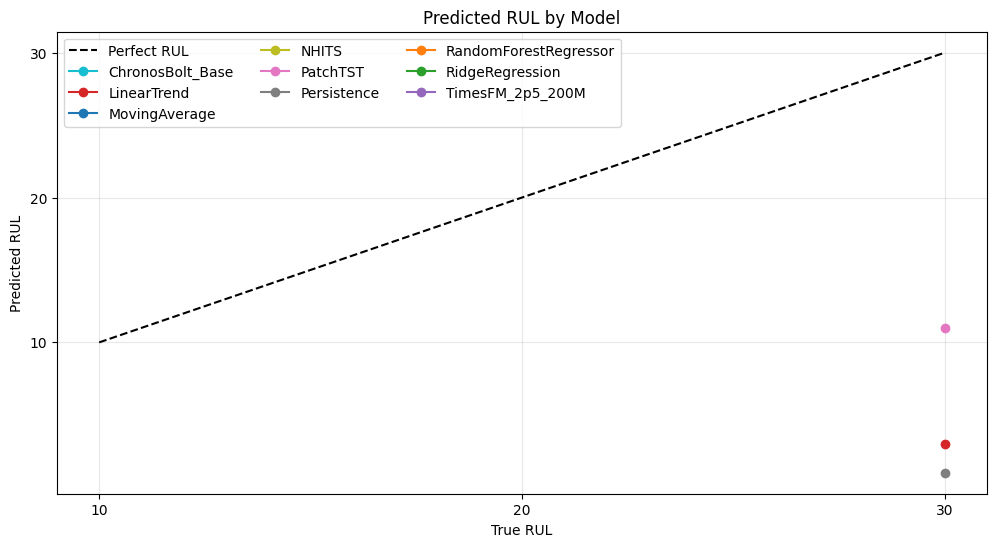

In [43]:
eol_rul_plot = rolling_rul_predictions.loc[
    rolling_rul_predictions[
        "true_event_in_horizon"
    ]
].copy()

MODEL_COLORS_RUL = {
    "Persistence": "tab:gray",
    "MovingAverage": "tab:blue",
    "LinearTrend": "tab:red",
    "RidgeRegression": "tab:green",
    "RandomForestRegressor": "tab:orange",
    "TimesFM_2p5_200M": "tab:purple",
    "ChronosBolt_Base": "tab:cyan",
    "NHITS": "tab:olive",
    "PatchTST": "tab:pink",
}

plt.figure(figsize=(12, 6))

plt.plot(
    HORIZONS,
    HORIZONS,
    color="black",
    linestyle="--",
    label="Perfect RUL",
)

for model_name, group in eol_rul_plot.groupby(
    "model_name"
):
    group = group.sort_values("true_rul")

    plt.plot(
        group["true_rul"],
        group["predicted_rul"],
        marker="o",
        color=MODEL_COLORS_RUL[model_name],
        label=model_name,
    )

plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")
plt.title("Predicted RUL by Model")
plt.xticks(HORIZONS)
plt.yticks(HORIZONS)
plt.grid(alpha=0.3)
plt.legend(ncol=3)
plt.show()

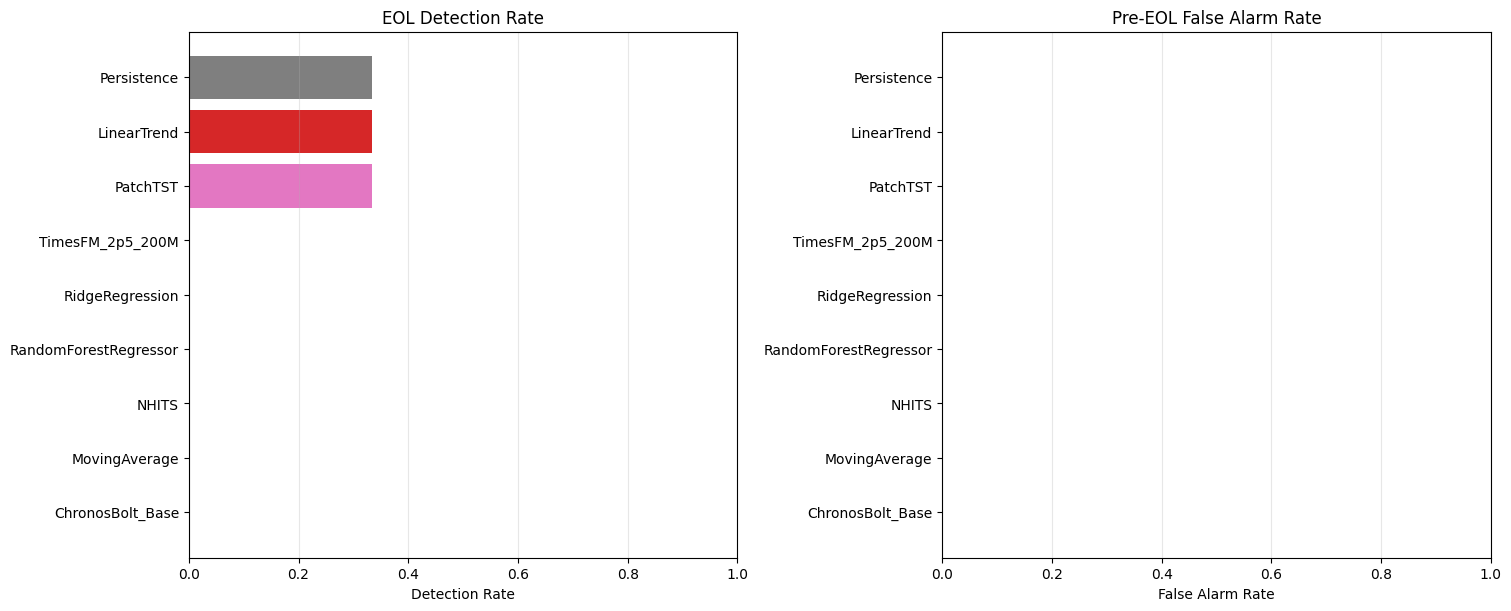

In [44]:
plot_metrics = (
    rolling_rul_metrics
    .sort_values("eol_detection_rate")
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 6),
    constrained_layout=True,
)

axes[0].barh(
    plot_metrics["model_name"],
    plot_metrics["eol_detection_rate"],
    color=[
        MODEL_COLORS_RUL[name]
        for name in plot_metrics["model_name"]
    ],
)
axes[0].set_title("EOL Detection Rate")
axes[0].set_xlabel("Detection Rate")
axes[0].set_xlim(0, 1)
axes[0].grid(axis="x", alpha=0.3)

axes[1].barh(
    plot_metrics["model_name"],
    plot_metrics["false_alarm_rate"],
    color=[
        MODEL_COLORS_RUL[name]
        for name in plot_metrics["model_name"]
    ],
)
axes[1].set_title("Pre-EOL False Alarm Rate")
axes[1].set_xlabel("False Alarm Rate")
axes[1].set_xlim(0, 1)
axes[1].grid(axis="x", alpha=0.3)

plt.show()

In [45]:
rolling_rul_predictions.to_csv(
    RUL_PREDICTIONS_CSV,
    index=False,
)
rolling_rul_predictions.to_parquet(
    RUL_PREDICTIONS_PARQUET,
    index=False,
)
rolling_rul_metrics.to_csv(
    RUL_METRICS_CSV,
    index=False,
)
rolling_decision_leaderboard.to_csv(
    DECISION_LEADERBOARD_CSV,
    index=False,
)
rolling_risk_summary.to_csv(
    RISK_SUMMARY_CSV,
    index=False,
)

csv_check = pd.read_csv(
    RUL_PREDICTIONS_CSV
)
parquet_check = pd.read_parquet(
    RUL_PREDICTIONS_PARQUET
)

assert csv_check.shape == parquet_check.shape
assert list(csv_check.columns) == list(
    parquet_check.columns
)

print("RUL predictions:", csv_check.shape)
print("RUL metrics:", rolling_rul_metrics.shape)
print(
    "Decision leaderboard:",
    rolling_decision_leaderboard.shape,
)

RUL predictions: (135, 31)
RUL metrics: (9, 22)
Decision leaderboard: (9, 24)
